# Job Recommendation System — Multimodal Data Generation

This notebook simulates multimodal recruitment data for a content-based job recommendation system.

**Data Overview:**
- **Job Description Data**: ~2000 Job Descriptions (Job title, industry, responsibility, skills) + ~2000 Candidate Resumes
- **Structured Data**: 5000 records with numerical, categorical, and ordinal features (with intentional missing values)

## 数据集特征说明 / Dataset Feature Reference

### df_jd — 职位数据集 / Job Description Dataset（2000 条/rows）

| 类别/Category | 字段/Field | 说明/Description |
|---|---|---|
| **标识/Identifier** | `jd_id` | 职位唯一编号 / Unique job ID（JD_0000） |
| **职位信息/Job Info** | `Job Title` | 职位名称 / Job title |
| | `Industry` | 所属行业 / Industry（12 个/industries） |
| | `job_level` | 职级 / Job level（Intern → VP，8 档/tiers） |
| | `Responsibilities` | 岗位职责描述 / Job responsibility text |
| | `Skills` | 技能要求 / Required skills（逗号分隔/comma-separated） |
| **地理/Location** | `base_location` | 工作城市 / Work city（14 个/cities） |
| **薪资/Salary** | `salary` | 薪资范围字符串 / Salary range string（如/e.g. `18k-22k/月`） |
| | `salary_mid` | 薪资中间值 / Salary midpoint（k RMB/月/month） |
| **招聘要求/Requirements** | `edu_req` | 学历要求 / Education requirement（高中/High School → 博士/Ph.D.） |
| | `exp_req` | 工作年限要求 / Experience requirement（0年 → 10年以上/10+ yrs） |
| | `working_hours` | 每周工时要求 / Weekly working hours requirement（<40 → >60） |
| **文本/Text** | `jd_text` | 拼接全文 / Concatenated full text（供/for BERT 向量化/vectorization） |

---

### df_struct — 候选人数据集 / Candidate Dataset（5000 条/rows）

| 类别/Category | 字段/Field | 说明/Description |
|---|---|---|
| **标识/Identifier** | `record_id` | 候选人唯一编号 / Unique candidate ID（REC_00001） |
| **数值特征/Numeric** | `years_experience` | 工作年限 / Years of experience（5% 缺失/missing） |
| | `expected_salary_k` | 期望薪资 / Expected salary（万/年 10k-CNY/year，范围/range 5-60，8% 缺失/missing） |
| | `age` | 年龄 / Age（由工作年限推算/derived from experience，6% 缺失/missing） |
| | `weekly_hours` | 每周可工作时长 / Available weekly hours（8% 缺失/missing） |
| | `num_applications` | 投递数量 / Number of applications submitted（泊松分布/Poisson，4% 缺失/missing） |
| **类别特征/Categorical** | `gender` | 性别 / Gender（Male 52% / Female 48%） |
| | `job_level` | 求职目标职级 / Target job level（偏初中级/skews junior） |
| | `industry` | 目标行业 / Target industry |
| | `city` | 所在城市 / Current city（7% 缺失/missing） |
| | `education_level` | 学历 / Education level（本科/Bachelor's 48%，硕士/Master's 37%，5% 缺失/missing） |
| | `political_affiliation` | 政治面貌 / Political affiliation（10% 缺失/missing） |
| **文本特征/Text** | `expected_title` | 期望职位名称 / Expected job title（~20% 含同义词扰动/with synonym perturbation） |
| | `skills` | 技能标签 / Skill tags（5-8 个/items，按行业采样/sampled by industry） |
| **有序编码/Ordinal** | `education_ordinal` | 学历有序编码 / Education ordinal encoding（0-3） |
| | `job_level_ordinal` | 职级有序编码 / Job level ordinal encoding（0-7） |
| **标签/Label** | `ground_truth_jd_id` | 最匹配职位 ID / Best-match JD ID（XGBoost 训练标签/training label） |

> **评分公式 / Scoring formula**：`行业匹配/Industry match × 3 + 职级接近度/Level proximity × 2 + 薪资匹配/Salary match × 2 + 学历达标/Education meets req × 1`

## 0. Environment Setup


In [2]:
import random
import numpy as np
import pandas as pd
from faker import Faker

# !pip install faker  # uncomment if needed

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
fake = Faker('en_US')
Faker.seed(SEED)

print('Libraries loaded successfully.')


Libraries loaded successfully.


## 1. Job Description Data
12个行业、每行业 10 职位、总计 120 个独立职位，每个职位固定 3 条职责描述, 生成单个JD数据时随机抽取一条。

手动将技能按业务深度分为 Core, Secondary 和 Tertiary，并赋予 75%, 50%, 25% 的抽取概率。

There are 12 industries, 10 job titles per industry, totaling 120 unique job titles. Each job title has 3 fixed job descriptions, and one title is randomly selected when generating a single job description.
We manually categorized skills into Core, Secondary, and Tertiary tiers based on business depth, assigning 75%, 50%, and 25% sampling probabilities respectively.

In [3]:
import pandas as pd
import random

# 12 行业、每行业 10 职位、总计 120 个独立职位，每个职位固定 3 条职责描述
ROLE_CONTEXT_LIBRARY = {
    # === FINTECH (金融科技) - 10 ===
    ('Quantitative Analyst', 'FinTech'): {
        'resps': [
            'Implement stochastic volatility models and Monte Carlo simulations for derivative pricing.',
            'Optimize high-frequency trading algorithms using tick-level market data and C++ low-latency systems.',
            'Conduct rigorous backtesting of quantitative strategies accounting for slippage and transaction costs.'
        ],
        'core': ['Stochastic Calculus', 'Quantitative Finance'], 'secondary': ['C++', 'Python'], 'tertiary': ['Kdb+/Q']
    },
    ('Risk Manager', 'FinTech'): {
        'resps': [
            'Calculate Value-at-Risk (VaR) and Expected Shortfall using historical and parametric approaches.',
            'Perform counterparty credit risk (CCR) assessments for complex OTC derivative portfolios.',
            'Design liquidity stress testing frameworks compliant with Basel III regulatory standards.'
        ],
        'core': ['Financial Risk Management', 'Basel III'], 'secondary': ['Stress Testing', 'SQL'], 'tertiary': ['SAS']
    },
    ('Compliance Officer', 'FinTech'): {
        'resps': [
            'Develop automated transaction monitoring rules to detect potential Anti-Money Laundering (AML) typologies.',
            'Ensure all customer onboarding workflows adhere to strict KYC and CIP regulations.',
            'Coordinate with regulatory bodies to submit suspicious activity reports (SARs) accurately.'
        ],
        'core': ['AML/KYC', 'Regulatory Compliance'], 'secondary': ['SQL', 'Risk Assessment'], 'tertiary': ['Auditing']
    },
    ('Blockchain Developer', 'FinTech'): {
        'resps': [
            'Design and deploy secure smart contracts on Ethereum for decentralized finance (DeFi) lending protocols.',
            'Optimize blockchain node architecture to reduce gas fees and handle high transaction throughput.',
            'Conduct rigorous security audits on Solidity codebases to prevent reentrancy and flash loan attacks.'
        ],
        'core': ['Solidity', 'Ethereum'], 'secondary': ['Cryptography', 'Web3.js'], 'tertiary': ['Go']
    },
    ('Algorithmic Trader', 'FinTech'): {
        'resps': [
            'Deploy statistical arbitrage and mean-reversion strategies across multi-asset electronic venues.',
            'Monitor real-time trading book exposures and auto-hedge delta/gamma risks dynamically.',
            'Analyze limit order book micro-structure to improve execution algorithms like VWAP and TWAP.'
        ],
        'core': ['Algorithmic Trading', 'Market Microstructure'], 'secondary': ['Python', 'Time Series Analysis'], 'tertiary': ['C++']
    },
    ('Credit Scorer', 'FinTech'): {
        'resps': [
            'Build alternative credit scoring models using non-traditional data sources like utility bills.',
            'Develop XGBoost and LightGBM classifiers to predict probability of default (PD) and LGD.',
            'Perform reject inference to correct sample bias in historical loan approval datasets.'
        ],
        'core': ['XGBoost', 'Credit Risk Modeling'], 'secondary': ['Logistic Regression', 'Python'], 'tertiary': ['SQL']
    },
    ('Fraud Analyst', 'FinTech'): {
        'resps': [
            'Utilize graph neural networks (GNNs) to uncover complex fraud rings and synthetic identity theft.',
            'Analyze real-time transaction streams to detect account takeover (ATO) and card-not-present fraud.',
            'Tune rule-based fraud detection engines to balance false positive rates with fraud capture.'
        ],
        'core': ['Fraud Detection', 'Anomaly Detection'], 'secondary': ['NetworkX', 'SQL'], 'tertiary': ['Python']
    },
    ('Investment Banker', 'FinTech'): {
        'resps': [
            'Construct complex financial models (DCF, LBO) to evaluate M&A targets in the tech sector.',
            'Prepare comprehensive pitch books and CIMs for capital raising and private placements.',
            'Analyze capital structure optimization and debt issuance scenarios for corporate clients.'
        ],
        'core': ['Financial Modeling', 'Valuation'], 'secondary': ['Excel', 'Corporate Finance'], 'tertiary': ['M&A']
    },
    ('Payments Architect', 'FinTech'): {
        'resps': [
            'Design highly available payment gateways capable of processing thousands of TPS.',
            'Integrate cross-border payment rails (SWIFT, SEPA) with modern RESTful APIs.',
            'Implement tokenization and P2PE to ensure PCI-DSS compliance across the transaction lifecycle.'
        ],
        'core': ['System Architecture', 'Payment Gateways'], 'secondary': ['Microservices', 'Java'], 'tertiary': ['PCI-DSS']
    },
    ('Actuarial Scientist', 'FinTech'): {
        'resps': [
            'Apply Generalized Linear Models (GLMs) to price novel InsurTech products dynamically.',
            'Perform reserving and claim severity modeling using historical loss run data.',
            'Evaluate the impact of climate change on long-tail casualty insurance lines.'
        ],
        'core': ['Actuarial Modeling', 'GLM'], 'secondary': ['R', 'SAS'], 'tertiary': ['Statistical Theory']
    },

    # === E-COMMERCE (电商) - 10 ===
    ('Search Relevance Engineer', 'E-Commerce'): {
        'resps': [
            'Implement Learning-to-Rank (LTR) algorithms to optimize product search NDCG and click-through rates.',
            'Develop dense vector retrieval systems using fine-tuned BERT embeddings for semantic search.',
            'Mine search query logs to build automated synonym generation and spell-correction pipelines.'
        ],
        'core': ['Elasticsearch', 'Learning to Rank'], 'secondary': ['Python', 'NLP'], 'tertiary': ['Vector Databases']
    },
    ('Growth Hacker', 'E-Commerce'): {
        'resps': [
            'Design viral acquisition loops and referral programs to decrease Customer Acquisition Cost (CAC).',
            'Conduct multivariate A/B testing on landing pages to optimize the user conversion funnel.',
            'Scrape competitor pricing and promotional data to inform dynamic pricing strategies.'
        ],
        'core': ['A/B Testing', 'Growth Marketing'], 'secondary': ['SQL', 'Web Analytics'], 'tertiary': ['Python']
    },
    ('Personalization Specialist', 'E-Commerce'): {
        'resps': [
            'Build collaborative filtering and matrix factorization models for personalized product recommendations.',
            'Deploy real-time contextual bandits to optimize homepage content targeting based on session behavior.',
            'Segment customer base using RFM analysis to tailor email marketing campaigns.'
        ],
        'core': ['Recommendation Systems', 'Machine Learning'], 'secondary': ['Python', 'Spark'], 'tertiary': ['SQL']
    },
    ('Supply Chain Planner', 'E-Commerce'): {
        'resps': [
            'Forecast SKU-level inventory demand using time-series models to prevent stockouts.',
            'Calculate optimal safety stock levels balancing holding costs against service level agreements.',
            'Coordinate with overseas suppliers to mitigate lead-time variability and port congestions.'
        ],
        'core': ['Demand Forecasting', 'Supply Chain Management'], 'secondary': ['Excel', 'SQL'], 'tertiary': ['ERP Systems']
    },
    ('Catalog Manager', 'E-Commerce'): {
        'resps': [
            'Maintain product taxonomy and metadata integrity across millions of active SKUs.',
            'Utilize computer vision to automate the tagging and categorization of incoming product images.',
            'Resolve duplicate listings and conflicting attribute data in the MDM system.'
        ],
        'core': ['Data Governance', 'Taxonomy'], 'secondary': ['PIM systems', 'SQL'], 'tertiary': ['Excel']
    },
    ('Conversion Optimizer', 'E-Commerce'): {
        'resps': [
            'Analyze user session recordings and heatmaps to identify friction points in the checkout process.',
            'Formulate hypotheses and execute rigorous A/B tests on CTA placements and page layouts.',
            'Correlate page load latency metrics with cart abandonment rates to drive engineering priorities.'
        ],
        'core': ['A/B Testing', 'UX Research'], 'secondary': ['Optimizely', 'Google Analytics'], 'tertiary': ['HTML/CSS']
    },
    ('LTV Analyst', 'E-Commerce'): {
        'resps': [
            'Model Customer Lifetime Value (LTV) using cohort analysis and survival modeling.',
            'Identify early indicators of customer churn and trigger automated retention workflows.',
            'Evaluate the long-term ROI of various marketing channels based on cohort profitability.'
        ],
        'core': ['Cohort Analysis', 'Customer Analytics'], 'secondary': ['SQL', 'Python'], 'tertiary': ['Tableau']
    },
    ('Warehouse Automation Dev', 'E-Commerce'): {
        'resps': [
            'Program PLCs and WMS integrations for automated conveyor sorting systems.',
            'Optimize picking paths for autonomous mobile robots (AMRs) using graph traversal algorithms.',
            'Develop real-time dashboards to monitor equipment OEE and throughput bottlenecks.'
        ],
        'core': ['ROS', 'Warehouse Management Systems'], 'secondary': ['C++', 'IoT'], 'tertiary': ['Python']
    },
    ('Digital Marketer', 'E-Commerce'): {
        'resps': [
            'Manage programmatic ad buying and retargeting campaigns across Google and Meta networks.',
            'Analyze ROAS and perform multi-touch attribution modeling using data-driven approaches.',
            'Optimize SEO strategies by conducting keyword research and technical site audits.'
        ],
        'core': ['Google Ads', 'SEO/SEM'], 'secondary': ['Digital Marketing', 'Data Analysis'], 'tertiary': ['Copywriting']
    },
    ('Customer Journey Mapper', 'E-Commerce'): {
        'resps': [
            'Synthesize qualitative interviews and clickstream data to build customer journey maps.',
            'Identify cross-channel friction points between mobile app browsing and desktop purchasing.',
            'Design service blueprints to align customer support processes with post-purchase experience.'
        ],
        'core': ['UX Strategy', 'Journey Mapping'], 'secondary': ['Figma', 'Qualitative Research'], 'tertiary': ['Data Visualization']
    },

    # === HEALTHCARE (医疗) - 10 ===
    ('Bioinformatics Scientist', 'Healthcare'): {
        'resps': [
            'Process and analyze NGS data to identify actionable genetic mutations.',
            'Develop scalable computational pipelines for RNA-Seq differential expression analysis.',
            'Integrate multi-omics datasets to uncover novel biomarkers for targeted oncology therapies.'
        ],
        'core': ['Genomics', 'Bioconductor'], 'secondary': ['R', 'Python'], 'tertiary': ['Bash/Shell']
    },
    ('Clinical Trial Coordinator', 'Healthcare'): {
        'resps': [
            'Manage subject recruitment, screening, and enrollment for Phase II/III clinical trials.',
            'Ensure rigorous compliance with Good Clinical Practice (GCP) and specific trial protocols.',
            'Oversee accurate data entry into EDC systems and resolve query logs.'
        ],
        'core': ['Clinical Trials', 'GCP'], 'secondary': ['EDC Systems', 'Patient Recruitment'], 'tertiary': ['Regulatory Compliance']
    },
    ('Health Informatics Specialist', 'Healthcare'): {
        'resps': [
            'Map legacy medical terminologies to standardized vocabularies like SNOMED CT and LOINC.',
            'Implement HL7 FHIR interoperability standards for data exchange between hospital systems.',
            'Design clinical decision support (CDS) alerts within the EHR to improve patient safety.'
        ],
        'core': ['HL7/FHIR', 'Health Informatics'], 'secondary': ['EHR/EMR Systems', 'SQL'], 'tertiary': ['Data Integration']
    },
    ('Epidemiologist', 'Healthcare'): {
        'resps': [
            'Design observational studies and calculate odds ratios to assess environmental risk factors.',
            'Develop spatio-temporal models to track and forecast the spread of infectious diseases.',
            'Analyze public health registries to evaluate the impact of vaccination programs.'
        ],
        'core': ['Epidemiology', 'Study Design'], 'secondary': ['SAS', 'R'], 'tertiary': ['Biostatistics']
    },
    ('Medical Imaging Researcher', 'Healthcare'): {
        'resps': [
            'Train 3D CNNs for tumor segmentation in MRI and CT scans.',
            'Apply generative adversarial networks (GANs) for synthetic medical image augmentation.',
            'Validate diagnostic accuracy of AI models against board-certified radiologist baselines.'
        ],
        'core': ['Computer Vision', 'Medical Imaging (DICOM)'], 'secondary': ['PyTorch', 'Deep Learning'], 'tertiary': ['Python']
    },
    ('EHR Systems Architect', 'Healthcare'): {
        'resps': [
            'Architect secure cloud infrastructure to host multi-tenant EHR databases.',
            'Optimize complex SQL queries to ensure sub-second response times for clinical staff.',
            'Implement disaster recovery protocols and backup restorations for sensitive patient data.'
        ],
        'core': ['System Architecture', 'Cloud Computing (AWS/Azure)'], 'secondary': ['SQL Tuning', 'Database Admin'], 'tertiary': ['Security']
    },
    ('Genomic Data Analyst', 'Healthcare'): {
        'resps': [
            'Perform variant calling and annotation using GATK best practices pipelines.',
            'Analyze genome-wide association studies (GWAS) to identify polygenic risk scores.',
            'Visualize complex genomic structural variations using tools like Circos and IGV.'
        ],
        'core': ['GATK', 'Genetics'], 'secondary': ['Python', 'R'], 'tertiary': ['Linux/Unix']
    },
    ('Patient Privacy Officer', 'Healthcare'): {
        'resps': [
            'Conduct risk assessments to ensure HIPAA and HITECH compliance across IT systems.',
            'Implement data de-identification and anonymization techniques for research datasets.',
            'Investigate potential protected health information (PHI) breaches and formulate plans.'
        ],
        'core': ['HIPAA/HITECH', 'Data Privacy'], 'secondary': ['Compliance Auditing', 'Risk Management'], 'tertiary': ['Legal Standards']
    },
    ('Biostatistician', 'Healthcare'): {
        'resps': [
            'Calculate statistical power and sample size requirements for clinical trial designs.',
            'Perform survival analysis (Kaplan-Meier, Cox Proportional Hazards) to evaluate efficacy.',
            'Author Statistical Analysis Plans (SAPs) for FDA regulatory submissions.'
        ],
        'core': ['Survival Analysis', 'Clinical Trial Design'], 'secondary': ['SAS', 'R'], 'tertiary': ['Statistical Inference']
    },
    ('Telemedicine Engineer', 'Healthcare'): {
        'resps': [
            'Develop low-latency WebRTC video streaming pipelines for remote consultations.',
            'Integrate IoT medical devices securely into the telehealth mobile application.',
            'Ensure end-to-end encryption of all synchronous communications to protect privacy.'
        ],
        'core': ['WebRTC', 'Mobile Development'], 'secondary': ['IoT Integration', 'Network Security'], 'tertiary': ['JavaScript']
    },

    # === EDTECH (教育科技) - 10 ===
    ('Learning Scientist', 'Education Technology'): {
        'resps': [
            'Apply cognitive psychology principles to evaluate digital learning interventions.',
            'Analyze student interaction logs to model knowledge tracing and skill acquisition.',
            'Design experimental studies to measure the impact of spaced repetition on retention.'
        ],
        'core': ['Cognitive Science', 'Educational Data Mining'], 'secondary': ['R', 'Experimental Design'], 'tertiary': ['Psychometrics']
    },
    ('Instructional Designer', 'Education Technology'): {
        'resps': [
            'Develop interactive multimedia content using authoring tools like Articulate Storyline.',
            'Align curriculum objectives with Bloom’s Taxonomy to ensure measurable outcomes.',
            'Collaborate with SMEs to translate complex topics into engaging digital modules.'
        ],
        'core': ['Instructional Design', 'Curriculum Development'], 'secondary': ['Articulate/Captivate', 'Pedagogy'], 'tertiary': ['Multimedia']
    },
    ('Adaptive Learning Dev', 'Education Technology'): {
        'resps': [
            'Implement Bayesian Knowledge Tracing (BKT) models to adjust question difficulty.',
            'Build recommendation engines that suggest personalized learning paths based on deficits.',
            'Develop backend APIs to serve real-time adaptive assessments during active sessions.'
        ],
        'core': ['Machine Learning', 'Algorithm Design'], 'secondary': ['Python', 'API Development'], 'tertiary': ['SQL']
    },
    ('EdTech Product Manager', 'Education Technology'): {
        'resps': [
            'Define product roadmaps for classroom management features based on teacher feedback.',
            'Prioritize feature backlogs balancing district compliance with user experience.',
            'Monitor DAU/MAU and feature adoption metrics to drive iterative improvements.'
        ],
        'core': ['Product Management', 'Agile/Scrum'], 'secondary': ['Data Analysis', 'User Research'], 'tertiary': ['Roadmapping']
    },
    ('Student Success Analyst', 'Education Technology'): {
        'resps': [
            'Develop predictive models to identify at-risk students likely to drop out of programs.',
            'Analyze cohort progression to evaluate effectiveness of academic advising interventions.',
            'Build interactive dashboards for administrators to monitor enrollment and retention KPIs.'
        ],
        'core': ['Predictive Modeling', 'Data Visualization'], 'secondary': ['SQL', 'Tableau/Power BI'], 'tertiary': ['Python']
    },
    ('LMS Architect', 'Education Technology'): {
        'resps': [
            'Design scalable backend architectures for LMS handling high-concurrency exams.',
            'Implement LTI standards to integrate third-party educational applications.',
            'Ensure the platform meets WCAG accessibility standards for students with disabilities.'
        ],
        'core': ['System Architecture', 'LTI Standards'], 'secondary': ['Cloud Computing', 'Database Design'], 'tertiary': ['Java/C#']
    },
    ('Curriculum Data Scientist', 'Education Technology'): {
        'resps': [
            'Utilize NLP to analyze student open-ended responses and automate grading rubrics.',
            'Cluster course syllabus data to identify gaps in degree program offerings.',
            'Correlate specific module completion rates with standardized test performance.'
        ],
        'core': ['NLP', 'Machine Learning'], 'secondary': ['Python', 'Text Mining'], 'tertiary': ['SQL']
    },
    ('Gamification Expert', 'Education Technology'): {
        'resps': [
            'Design reward loops, badges, and leaderboard mechanics to increase engagement.',
            'Balance virtual economy elements within educational games to maintain motivation.',
            'A/B test gamified UI elements to maximize completion rates of homework.'
        ],
        'core': ['Game Design', 'Behavioral Psychology'], 'secondary': ['A/B Testing', 'UI/UX Design'], 'tertiary': ['Data Analysis']
    },
    ('Online Tutor Coordinator', 'Education Technology'): {
        'resps': [
            'Optimize scheduling algorithms to match student demand with subject-expert tutors.',
            'Analyze post-session survey data and transcripts to evaluate tutor quality.',
            'Develop training materials to improve online pedagogical skills and troubleshooting.'
        ],
        'core': ['Operations Management', 'Scheduling Algorithms'], 'secondary': ['Data Analysis', 'Training'], 'tertiary': ['Communication']
    },
    ('UX Researcher (Edu)', 'Education Technology'): {
        'resps': [
            'Conduct usability testing with K-12 students for age-appropriate interface design.',
            'Perform heuristic evaluations on mobile learning apps to identify pain points.',
            'Synthesize teacher ethnographic research into actionable personas for product teams.'
        ],
        'core': ['Usability Testing', 'Qualitative Research'], 'secondary': ['HCI', 'Wireframing'], 'tertiary': ['Survey Design']
    },

    # === LOGISTICS (物流) - 10 ===
    ('Route Optimization Eng', 'Logistics'): {
        'resps': [
            'Implement heuristic solvers for the CVRPTW using OR-Tools.',
            'Integrate real-time traffic APIs to dynamically re-route delivery fleets.',
            'Optimize long-haul freight network topologies to minimize empty miles.'
        ],
        'core': ['OR-Tools', 'Optimization Algorithms'], 'secondary': ['Python', 'GIS'], 'tertiary': ['C++']
    },
    ('Fleet Ops Manager', 'Logistics'): {
        'resps': [
            'Monitor real-time telematics data to enforce driver safety and reduce idling.',
            'Schedule preventative maintenance for heavy-duty trucks to maximize uptime.',
            'Manage vendor relationships for fuel procurement and maintenance services.'
        ],
        'core': ['Fleet Management', 'Telematics'], 'secondary': ['Operations Research', 'Vendor Management'], 'tertiary': ['Excel']
    },
    ('Warehouse Sys Analyst', 'Logistics'): {
        'resps': [
            'Configure and optimize WMS for complex put-away and picking logic.',
            'Analyze SKU velocity to redesign warehouse slotting and reduce travel time.',
            'Troubleshoot EDI integrations between the WMS and enterprise ERP systems.'
        ],
        'core': ['WMS (Manhattan/Blue Yonder)', 'SQL'], 'secondary': ['Process Optimization', 'EDI'], 'tertiary': ['Data Analysis']
    },
    ('Demand Forecaster', 'Logistics'): {
        'resps': [
            'Develop baseline forecasts combining historical shipments with seasonal indices.',
            'Incorporate macroeconomic indicators into advanced machine learning forecasts.',
            'Lead the S&OP consensus meetings with cross-functional supply chain teams.'
        ],
        'core': ['Time Series Forecasting', 'S&OP Process'], 'secondary': ['Python', 'Excel/VBA'], 'tertiary': ['Statistical Modeling']
    },
    ('International Trade Comp', 'Logistics'): {
        'resps': [
            'Classify products according to HTS for global customs clearance.',
            'Audit import/export documentation to ensure compliance with ITAR/EAR regulations.',
            'Manage free trade agreement (FTA) qualifications to optimize tariff duties.'
        ],
        'core': ['Customs Regulations', 'HTS Classification'], 'secondary': ['Trade Compliance', 'Auditing'], 'tertiary': ['Supply Chain Law']
    },
    ('Last-Mile Delivery Spec', 'Logistics'): {
        'resps': [
            'Design crowdsourced delivery models to handle peak seasonal volume.',
            'Analyze proof-of-delivery (POD) metrics to reduce failed attempts and theft.',
            'Optimize placement of micro-fulfillment centers based on demographic density.'
        ],
        'core': ['Logistics Planning', 'Urban Logistics'], 'secondary': ['Data Analysis', 'Vendor Management'], 'tertiary': ['GIS']
    },
    ('Supply Chain Security', 'Logistics'): {
        'resps': [
            'Conduct risk assessments on high-value transit routes to prevent cargo theft.',
            'Implement C-TPAT compliant security protocols for international warehouse facilities.',
            'Deploy IoT smart locks and geo-fencing to monitor freight integrity in real-time.'
        ],
        'core': ['Risk Assessment', 'Supply Chain Management'], 'secondary': ['Physical Security', 'IoT Security'], 'tertiary': ['Compliance']
    },
    ('IoT Telemetry Analyst', 'Logistics'): {
        'resps': [
            'Process streaming sensor data from cold chain shipments to ensure compliance.',
            'Build anomaly detection models to alert operations of potential equipment failures.',
            'Design scalable data pipelines to ingest billions of GPS pings from the fleet.'
        ],
        'core': ['Kafka', 'IoT Platforms'], 'secondary': ['Spark', 'Python'], 'tertiary': ['Time Series Databases']
    },
    ('Freight Forwarder', 'Logistics'): {
        'resps': [
            'Negotiate spot and contract rates with ocean carriers and airlines.',
            'Coordinate complex multi-modal transportation routing for oversized cargo.',
            'Manage preparation of bills of lading, commercial invoices, and letters of credit.'
        ],
        'core': ['Freight Forwarding', 'Incoterms'], 'secondary': ['Negotiation', 'Logistics Coordination'], 'tertiary': ['Customer Service']
    },
    ('Inventory Controller', 'Logistics'): {
        'resps': [
            'Execute cycle counting programs and root-cause analysis for discrepancies.',
            'Reconcile physical inventory with systemic records in the ERP for accuracy.',
            'Optimize slow-moving inventory disposition strategies to free up warehouse space.'
        ],
        'core': ['Inventory Management', 'Auditing'], 'secondary': ['ERP Systems', 'Excel'], 'tertiary': ['Analytical Skills']
    },

    # === MANUFACTURING (制造) - 10 ===
    ('Predictive Maint Eng', 'Manufacturing'): {
        'resps': [
            'Analyze vibration data to predict failures in CNC machines.',
            'Train machine learning models on sensor data to estimate RUL.',
            'Integrate predictive alerts into the CMMS to optimize repair schedules.'
        ],
        'core': ['Signal Processing', 'Reliability Engineering'], 'secondary': ['Python', 'Machine Learning'], 'tertiary': ['IoT']
    },
    ('Quality Control Spec', 'Manufacturing'): {
        'resps': [
            'Implement Statistical Process Control (SPC) charts for production monitoring.',
            'Conduct root cause analysis using 8D and Ishikawa diagrams for out-of-spec batches.',
            'Develop computer vision systems to detect surface defects on manufactured parts.'
        ],
        'core': ['SPC', 'Six Sigma'], 'secondary': ['Minitab', 'Computer Vision'], 'tertiary': ['Quality Assurance']
    },
    ('Automation Architect', 'Manufacturing'): {
        'resps': [
            'Design SCADA system architectures for new plant expansions.',
            'Program PLCs and HMI interfaces for continuous process manufacturing.',
            'Ensure data integration between shop floor control systems and the ERP.'
        ],
        'core': ['PLC Programming', 'SCADA'], 'secondary': ['Automation', 'Industrial Networks'], 'tertiary': ['System Integration']
    },
    ('IIoT Integrator', 'Manufacturing'): {
        'resps': [
            'Deploy edge computing devices to aggregate telemetry from legacy equipment.',
            'Implement MQTT and OPC-UA protocols for machine-to-cloud transmission.',
            'Build digital twin models to simulate the impact of line speed on throughput.'
        ],
        'core': ['MQTT/OPC-UA', 'IoT Architecture'], 'secondary': ['Edge Computing', 'Python'], 'tertiary': ['Digital Twin']
    },
    ('SC Risk Manager', 'Manufacturing'): {
        'resps': [
            'Map the N-tier supplier network to identify single points of failure.',
            'Develop business continuity plans for critical raw material shortages.',
            'Monitor global commodity pricing indices to recommend strategic hedging.'
        ],
        'core': ['Risk Management', 'Supply Chain Mapping'], 'secondary': ['Financial Analysis', 'Business Continuity'], 'tertiary': ['Data Analysis']
    },
    ('Robotics Programmer', 'Manufacturing'): {
        'resps': [
            'Program multi-axis industrial arms for precision welding and assembly.',
            'Develop inverse kinematics for complex robotic path planning.',
            'Integrate 3D vision systems with end-effectors for bin picking.'
        ],
        'core': ['Robotics Programming', 'Kinematics'], 'secondary': ['C++', 'Computer Vision'], 'tertiary': ['ROS']
    },
    ('Smart Factory Consultant', 'Manufacturing'): {
        'resps': [
            'Assess maturity of facilities to develop Industry 4.0 transformation roadmaps.',
            'Calculate ROI and payback periods for capital investments in automation.',
            'Lead change management initiatives to upskill the workforce for data-driven ops.'
        ],
        'core': ['Industry 4.0', 'Manufacturing Execution Systems (MES)'], 'secondary': ['Consulting', 'Project Management'], 'tertiary': ['Change Management']
    },
    ('Materials Scientist', 'Manufacturing'): {
        'resps': [
            'Conduct failure analysis (SEM, XRD) on fatigued mechanical components.',
            'Develop novel polymer composites to reduce weight of aerospace parts.',
            'Optimize heat treatment processes to maximize tensile strength and durability.'
        ],
        'core': ['Materials Science', 'Design of Experiments (DOE)'], 'secondary': ['Spectroscopy', 'Data Analysis'], 'tertiary': ['Chemistry']
    },
    ('Lean Six Sigma Lead', 'Manufacturing'): {
        'resps': [
            'Lead DMAIC projects to reduce cycle times and scrap rates.',
            'Facilitate VSM workshops to eliminate non-value-added activities.',
            'Implement Kanban and 5S methodologies to optimize inventory flow.'
        ],
        'core': ['Lean Manufacturing', 'Six Sigma Black Belt'], 'secondary': ['Process Improvement', 'Minitab'], 'tertiary': ['Project Management']
    },
    ('Production Scheduler', 'Manufacturing'): {
        'resps': [
            'Develop master production schedules optimizing machine changeovers.',
            'Run MRP cycles to ensure timely delivery of raw components.',
            'Adjust daily plans in response to unexpected machine downtime or rush orders.'
        ],
        'core': ['Production Planning', 'ERP/MRP Systems'], 'secondary': ['Excel', 'Operations Management'], 'tertiary': ['Problem Solving']
    },

    # === GAMING (游戏) - 10 ===
    ('Economy Designer', 'Gaming'): {
        'resps': [
            'Model virtual currency faucets and sinks to maintain stability.',
            'Simulate loot box drop rates to balance player progression pacing.',
            'Analyze telemetry data to detect and mitigate inflation caused by bots.'
        ],
        'core': ['Economy Modeling', 'Game Theory'], 'secondary': ['Excel', 'Python'], 'tertiary': ['Data Analysis']
    },
    ('Gameplay Programmer', 'Gaming'): {
        'resps': [
            'Implement character movement and combat mechanics in Unreal Engine.',
            'Optimize game loop logic to maintain stable 60 FPS on consoles.',
            'Collaborate with designers to ensure responsive input handling.'
        ],
        'core': ['C++', '3D Math'], 'secondary': ['Unreal Engine', 'Unity'], 'tertiary': ['C#']
    },
    ('Monetization Analyst', 'Gaming'): {
        'resps': [
            'Design models to identify high-value players and predict LTV.',
            'Analyze A/B test results on store UI layouts to maximize conversion.',
            'Evaluate the cannibalization effect of new cosmetic item releases.'
        ],
        'core': ['A/B Testing', 'Monetization Strategy'], 'secondary': ['SQL', 'Python'], 'tertiary': ['Data Visualization']
    },
    ('Behavior Researcher', 'Gaming'): {
        'resps': [
            'Apply clustering algorithms to segment player base by playstyle.',
            'Predict player churn using survival analysis on engagement metrics.',
            'Utilize NLP on chat logs to identify toxicity and improve moderation.'
        ],
        'core': ['Machine Learning', 'Psychometrics'], 'secondary': ['Python', 'SQL'], 'tertiary': ['NLP']
    },
    ('Graphics Engine Dev', 'Gaming'): {
        'resps': [
            'Implement real-time ray tracing features using DirectX 12 or Vulkan.',
            'Write custom shaders for post-processing effects and environmental lighting.',
            'Profile GPU bottlenecks to optimize draw calls and overdraw.'
        ],
        'core': ['DirectX/Vulkan', 'Shader Programming'], 'secondary': ['C++', 'Computer Graphics'], 'tertiary': ['GPU Profiling']
    },
    ('Anti-Cheat Engineer', 'Gaming'): {
        'resps': [
            'Reverse-engineer aimbots and wallhacks to develop detection signatures.',
            'Analyze telemetry data for statistically impossible reaction times.',
            'Implement kernel-level security measures to protect game memory integrity.'
        ],
        'core': ['Reverse Engineering', 'Cybersecurity'], 'secondary': ['C/C++', 'Assembly'], 'tertiary': ['Data Analysis']
    },
    ('Live-Ops Manager', 'Gaming'): {
        'resps': [
            'Plan and execute the cadence of live events and seasonal battle passes.',
            'Monitor server stability and concurrency during major content updates.',
            'Adjust balance parameters based on real-time meta-analysis.'
        ],
        'core': ['Live Operations', 'Project Management'], 'secondary': ['Data Analysis', 'Communication'], 'tertiary': ['Agile']
    },
    ('Technical Narrative', 'Gaming'): {
        'resps': [
            'Implement branching dialogue trees using scripting languages like Lua.',
            'Integrate VO assets into the engine and manage localization pipelines.',
            'Design narrative events that react dynamically to player choices.'
        ],
        'core': ['Scripting (Lua/Python)', 'Logic Design'], 'secondary': ['Narrative Design', 'Game Engines'], 'tertiary': ['Creative Writing']
    },
    ('Server Infra Eng', 'Gaming'): {
        'resps': [
            'Architect scalable matchmaking systems based on player MMR.',
            'Develop authoritative server logic to prevent desync in multiplayer.',
            'Optimize database queries for handling millions of concurrent writes.'
        ],
        'core': ['Network Programming', 'Cloud Architecture (AWS)'], 'secondary': ['C++', 'Go'], 'tertiary': ['Databases']
    },
    ('UI/UX Game Designer', 'Gaming'): {
        'resps': [
            'Design intuitive HUD and inventory menus for cross-platform play.',
            'Create interactive prototypes for skill tree and progression systems.',
            'Conduct eye-tracking studies to evaluate cognitive load during gameplay.'
        ],
        'core': ['UI/UX Design', 'Wireframing'], 'secondary': ['Figma', 'Adobe Suite'], 'tertiary': ['User Research']
    },

    # === MEDIA & ENTERTAINMENT (媒体娱乐) - 10 ===
    ('Streaming Video Eng', 'Media'): {
        'resps': [
            'Implement ABR algorithms to optimize playback quality under network constraints.',
            'Configure cloud-based transcoding pipelines using FFmpeg.',
            'Monitor CDN edge node performance to minimize buffering and latency.'
        ],
        'core': ['Video Codecs (H.264/H.265)', 'CDN Architecture'], 'secondary': ['FFmpeg', 'C++'], 'tertiary': ['Python']
    },
    ('Content Rec Scientist', 'Media'): {
        'resps': [
            'Build deep learning models to personalize content discovery.',
            'Develop reinforcement learning agents to optimize user watch time.',
            'Address cold-start problems using plot summaries and metadata.'
        ],
        'core': ['Recommendation Systems', 'Deep Learning'], 'secondary': ['Python', 'PyTorch'], 'tertiary': ['Spark']
    },
    ('Digital Rights Manager', 'Media'): {
        'resps': [
            'Implement Multi-DRM solutions to protect premium VOD content.',
            'Manage territorial licensing windows and content availability.',
            'Audit platform usage data to identify potential piracy networks.'
        ],
        'core': ['DRM Technologies', 'Content Licensing'], 'secondary': ['Copyright Law', 'Data Analysis'], 'tertiary': ['SQL']
    },
    ('Audience Analytics', 'Media'): {
        'resps': [
            'Analyze viewership data to evaluate the ROI of original productions.',
            'Segment audiences by engagement patterns to target marketing.',
            'Forecast viewership churn based on content consumption decline.'
        ],
        'core': ['Audience Segmentation', 'Predictive Modeling'], 'secondary': ['SQL', 'Tableau'], 'tertiary': ['Python']
    },
    ('Visual Effects TD', 'Media'): {
        'resps': [
            'Develop custom Python tools for Maya and Houdini pipelines.',
            'Optimize render farm allocation for high-resolution CGI sequences.',
            'Troubleshoot procedural simulations for fluid and cloth dynamics.'
        ],
        'core': ['Pipeline Development', 'Computer Graphics'], 'secondary': ['Python', 'Houdini/Maya'], 'tertiary': ['C++']
    },
    ('AdTech Systems Arch', 'Media'): {
        'resps': [
            'Design Server-Side Ad Insertion (SSAI) for live streaming.',
            'Integrate with DSPs and SSPs using the OpenRTB protocol.',
            'Optimize ad delivery for maximum fill rate and minimum latency.'
        ],
        'core': ['AdTech (OpenRTB)', 'System Architecture'], 'secondary': ['Java/Go', 'High Throughput'], 'tertiary': ['SQL']
    },
    ('Sound Engine Dev', 'Media'): {
        'resps': [
            'Integrate audio middleware like Wwise into custom engines.',
            'Develop spatial audio algorithms for immersive VR experiences.',
            'Optimize DSP chains for real-time effects on mobile devices.'
        ],
        'core': ['Audio Programming', 'DSP'], 'secondary': ['C++', 'Wwise/FMOD'], 'tertiary': ['Acoustics']
    },
    ('Social Strategist', 'Media'): {
        'resps': [
            'Utilize social listening tools to monitor brand sentiment.',
            'Design content calendars that optimize post timing for engagement.',
            'Analyze the Earned Media Value (EMV) of influencer partnerships.'
        ],
        'core': ['Social Media Analytics', 'Content Strategy'], 'secondary': ['Marketing', 'Data Analysis'], 'tertiary': ['Copywriting']
    },
    ('Broadcast Engineer', 'Media'): {
        'resps': [
            'Manage satellite and IP-based transmission for live sports events.',
            'Configure IP routing systems for modern broadcast facilities.',
            'Troubleshoot signal chain issues in real-time during live air.'
        ],
        'core': ['Broadcast Engineering', 'Video Routing'], 'secondary': ['RF Engineering', 'Networking'], 'tertiary': ['Troubleshooting']
    },
    ('Interactive Producer', 'Media'): {
        'resps': [
            'Manage the lifecycle of AR/VR interactive media experiences.',
            'Coordinate between creative directors and engineering teams.',
            'Track project budgets and timelines using Agile methodologies.'
        ],
        'core': ['Project Management', 'AR/VR Tech'], 'secondary': ['Agile/Scrum', 'Budgeting'], 'tertiary': ['Communication']
    },

    # === RETAIL (零售) - 10 ===
    ('Category Manager', 'Retail'): {
        'resps': [
            'Analyze POS data to optimize product assortment and shelf space.',
            'Negotiate pricing and promotional terms with FMCG vendors.',
            'Develop markdown strategies to optimize seasonal inventory turnover.'
        ],
        'core': ['Category Management', 'Pricing Strategy'], 'secondary': ['Data Analysis', 'Negotiation'], 'tertiary': ['Excel']
    },
    ('Visual Merchandiser', 'Retail'): {
        'resps': [
            'Conduct A/B testing on store planograms to maximize conversion.',
            'Analyze foot-traffic heatmaps to optimize store layout design.',
            'Correlate display changes with product-level sales lift.'
        ],
        'core': ['Visual Merchandising', 'Space Planning'], 'secondary': ['Data Analysis', 'A/B Testing'], 'tertiary': ['Excel']
    },
    ('Omnichannel Strategist', 'Retail'): {
        'resps': [
            'Design BOPIS (Buy Online, Pick Up In Store) workflows.',
            'Analyze cross-channel attribution to evaluate marketing spend.',
            'Harmonize loyalty data to build unified customer profiles.'
        ],
        'core': ['Omnichannel Retail', 'Strategy Development'], 'secondary': ['Data Analysis', 'E-commerce'], 'tertiary': ['Project Management']
    },
    ('Loss Prevention Spec', 'Retail'): {
        'resps': [
            'Utilize predictive analytics to identify potential internal theft.',
            'Implement RFID technologies to track and reduce shrinkage.',
            'Conduct audits on cash-handling and inventory management.'
        ],
        'core': ['Loss Prevention', 'Auditing'], 'secondary': ['Data Analysis', 'Physical Security'], 'tertiary': ['SQL']
    },
    ('CRM Data Analyst', 'Retail'): {
        'resps': [
            'Segment loyalty members based on CLV and purchase frequency.',
            'Calculate the incremental lift of personalized email campaigns.',
            'Maintain data hygiene and privacy standards within the CRM.'
        ],
        'core': ['Marketing Analytics', 'CRM Systems (Salesforce)'], 'secondary': ['SQL', 'Python'], 'tertiary': ['A/B Testing']
    },
    ('Store Planner', 'Retail'): {
        'resps': [
            'Determine stock allocations for new store openings.',
            'Manage store-to-store inventory transfers to balance supply.',
            'Analyze regional sales trends to inform macro-allocations.'
        ],
        'core': ['Inventory Planning', 'Retail Math'], 'secondary': ['Excel', 'Data Analysis'], 'tertiary': ['ERP Systems']
    },
    ('Inv Optimization Lead', 'Retail'): {
        'resps': [
            'Develop stochastic models for determining safety stock levels.',
            'Analyze supplier OTIF performance to optimize lead times.',
            'Design automated replenishment algorithms for staple items.'
        ],
        'core': ['Inventory Optimization', 'Operations Research'], 'secondary': ['SQL', 'Python'], 'tertiary': ['Supply Chain']
    },
    ('Buying Coordinator', 'Retail'): {
        'resps': [
            'Generate purchase orders and track shipments from vendors.',
            'Analyze weekly sales reports to recommend reorder quantities.',
            'Communicate with vendors regarding quality and delivery issues.'
        ],
        'core': ['Procurement', 'Vendor Management'], 'secondary': ['Excel', 'Data Entry'], 'tertiary': ['Communication']
    },
    ('Shopper Insights', 'Retail'): {
        'resps': [
            'Design ethnographic studies to understand shopper behavior.',
            'Synthesize survey data regarding brand perception and price.',
            'Present trend reports to leadership to inform seasonal buying.'
        ],
        'core': ['Qualitative Research', 'Market Research'], 'secondary': ['Survey Design', 'Data Visualization'], 'tertiary': ['SPSS']
    },
    ('POS Systems Dev', 'Retail'): {
        'resps': [
            'Develop custom features for enterprise POS software.',
            'Integrate mobile wallet and contactless payment APIs.',
            'Ensure POS architecture supports offline-mode transactions.'
        ],
        'core': ['POS Architecture', 'API Integration'], 'secondary': ['C# / Java', 'Database Management'], 'tertiary': ['Networking']
    },

    # === TELECOMMUNICATIONS (电信) - 10 ===
    ('5G Network Architect', 'Telecom'): {
        'resps': [
            'Design 5G Standalone (SA) core topologies using NFV/SDN.',
            'Develop network slicing strategies for diverse IoT use cases.',
            'Optimize MEC (Multi-access Edge Computing) deployments.'
        ],
        'core': ['5G Architecture', 'Network Slicing'], 'secondary': ['NFV/SDN', 'Cloud Computing'], 'tertiary': ['System Design']
    },
    ('RF Optimization Eng', 'Telecom'): {
        'resps': [
            'Analyze drive test data to optimize antenna tilt and azimuth.',
            'Resolve interference issues in dense urban 4G/5G networks.',
            'Perform capacity planning for cell sites during peak usage.'
        ],
        'core': ['RF Engineering', 'Telecom Fundamentals'], 'secondary': ['Atoll / Mentum Planet', 'Data Analysis'], 'tertiary': ['Troubleshooting']
    },
    ('Billing Analyst', 'Telecom'): {
        'resps': [
            'Audit CDRs (Call Detail Records) to identify revenue leakage.',
            'Configure complex tariff plans and discounts in the billing engine.',
            'Analyze data usage patterns to forecast future pricing impact.'
        ],
        'core': ['Revenue Assurance', 'Billing Systems'], 'secondary': ['SQL', 'Data Analysis'], 'tertiary': ['Excel']
    },
    ('OSS/BSS Developer', 'Telecom'): {
        'resps': [
            'Develop APIs integrating OSS with BSS for automated fulfillment.',
            'Automate provisioning workflows for fiber and mobile activations.',
            'Maintain microservices for real-time network alarm monitoring.'
        ],
        'core': ['OSS/BSS Systems', 'Telecom Standards'], 'secondary': ['Java', 'Microservices'], 'tertiary': ['API Development']
    },
    ('Fiber Planner', 'Telecom'): {
        'resps': [
            'Design OSP (Outside Plant) fiber routes using GIS software.',
            'Calculate optical link budgets for FTTH network deployments.',
            'Coordinate right-of-way permitting for fiber trenching projects.'
        ],
        'core': ['OSP Design', 'GIS (ArcGIS/QGIS)'], 'secondary': ['Optical Engineering', 'AutoCAD'], 'tertiary': ['Project Management']
    },
    ('Telco Cyber Specialist', 'Telecom'): {
        'resps': [
            'Monitor signaling protocols (SS7/Diameter) to block spoofing.',
            'Deploy DDoS mitigation strategies for core routing infra.',
            'Conduct vulnerability assessments on CPE and IoT devices.'
        ],
        'core': ['Signaling Security', 'Network Security'], 'secondary': ['Wireshark', 'DDoS Mitigation'], 'tertiary': ['Penetration Testing']
    },
    ('Signal Processing Eng', 'Telecom'): {
        'resps': [
            'Design advanced modulation schemes for satellite comms.',
            'Implement Massive MIMO beamforming algorithms.',
            'Optimize PHY layer algorithms for power and throughput.'
        ],
        'core': ['Signal Processing', 'Information Theory'], 'secondary': ['MATLAB', 'DSP'], 'tertiary': ['C/C++']
    },
    ('Spectrum Manager', 'Telecom'): {
        'resps': [
            'Analyze spectrum utilization for refarming legacy bands.',
            'Conduct interference studies for regulatory compliance.',
            'Prepare technical filings for spectrum auctions.'
        ],
        'core': ['Regulatory Compliance', 'Spectrum Analysis'], 'secondary': ['RF Engineering', 'Data Analysis'], 'tertiary': ['Technical Writing']
    },
    ('VoIP Admin', 'Telecom'): {
        'resps': [
            'Configure and maintain SIP trunking and Session Border Controllers.',
            'Troubleshoot call flow issues using packet capture analysis.',
            'Implement QoS policies to prioritize voice and video traffic.'
        ],
        'core': ['SIP/VoIP', 'Networking (QoS)'], 'secondary': ['Wireshark', 'SBC Config'], 'tertiary': ['Linux']
    },
    ('Telco Operations Lead', 'Telecom'): {
        'resps': [
            'Manage field technician schedules for fiber repair and install.',
            'Ensure compliance with OSHA safety standards for tower work.',
            'Perform audits on macro site construction and upgrades.'
        ],
        'core': ['Operations Management', 'Safety Compliance'], 'secondary': ['Project Management', 'Infrastructure'], 'tertiary': ['Leadership']
    },

    # === REAL ESTATE (房地产) - 10 ===
    ('PropTech Product Mgr', 'Real Estate'): {
        'resps': [
            'Define requirements for online lease negotiation features.',
            'Analyze search data to optimize residential property discovery.',
            'Manage integrations with 3D virtual tour and AR software.'
        ],
        'core': ['Product Management', 'PropTech Market'], 'secondary': ['Agile', 'Data Analysis'], 'tertiary': ['UX/UI']
    },
    ('Valuation Analyst', 'Real Estate'): {
        'resps': [
            'Construct DCF models for commercial property acquisitions.',
            'Analyze market cap rates and rent comparables in key metros.',
            'Draft investment memorandums for institutional capital partners.'
        ],
        'core': ['Argus', 'Real Estate Economics'], 'secondary': ['Financial Modeling', 'Valuation'], 'tertiary': ['Excel']
    },
    ('Leasing Ops Lead', 'Real Estate'): {
        'resps': [
            'Analyze tenant roll-over risk and develop retention strategies.',
            'Optimize the automation of tenant onboarding and vetting.',
            'Monitor local market rent growth to inform pricing strategy.'
        ],
        'core': ['Lease Administration', 'Operations Management'], 'secondary': ['Property Management Software', 'Data Analysis'], 'tertiary': ['Negotiation']
    },
    ('Urban Planner (Tech)', 'Real Estate'): {
        'resps': [
            'Utilize GIS for spatial analysis of new development sites.',
            'Model the traffic and environmental impact of mixed-use projects.',
            'Draft proposals for zoning variances and planning boards.'
        ],
        'core': ['Urban Planning', 'GIS (ArcGIS)'], 'secondary': ['AutoCAD', 'Environmental Regs'], 'tertiary': ['Data Visualization']
    },
    ('Smart Building Arch', 'Real Estate'): {
        'resps': [
            'Design IoT networks integrating HVAC, lighting, and security.',
            'Develop data pipelines for building-wide energy optimization.',
            'Ensure the cybersecurity of operational technology (OT) networks.'
        ],
        'core': ['BMS Systems', 'IoT Architecture'], 'secondary': ['Network Security', 'Python'], 'tertiary': ['Systems Integration']
    },
    ('RE Portfolio Strategist', 'Real Estate'): {
        'resps': [
            'Assess macro indicators to determine REIT sector allocations.',
            'Evaluate climate change risk on property valuations.',
            'Develop geographic diversification strategies for office portfolios.'
        ],
        'core': ['Risk Modeling', 'Portfolio Management'], 'secondary': ['Financial Analysis', 'Macroeconomics'], 'tertiary': ['Python/R']
    },
    ('Investment Analyst', 'Real Estate'): {
        'resps': [
            'Underwrite transactions for ground-up development projects.',
            'Perform financial due diligence on multi-family assets.',
            'Track debt market trends for loan-to-value recommendations.'
        ],
        'core': ['Underwriting', 'Due Diligence'], 'secondary': ['Financial Modeling', 'Excel'], 'tertiary': ['Corporate Finance']
    },
    ('BIM Coordinator', 'Real Estate'): {
        'resps': [
            'Manage 3D BIM models for clash detection during construction.',
            'Establish data naming standards within Autodesk Revit.',
            'Automate the extraction of quantity takeoffs from BIM models.'
        ],
        'core': ['BIM Coordination', '3D Modeling'], 'secondary': ['Revit', 'Navisworks'], 'tertiary': ['Construction Knowledge']
    },
    ('GIS Specialist (RE)', 'Real Estate'): {
        'resps': [
            'Develop proprietary web maps for site selection analysis.',
            'Perform spatial geoprocessing for retail catchment areas.',
            'Maintain the integrity of spatial databases for land parcels.'
        ],
        'core': ['Spatial Databases', 'GIS (ArcGIS/QGIS)'], 'secondary': ['Python (GeoPandas)', 'Cartography'], 'tertiary': ['Web GIS']
    },
    ('Project Controller', 'Real Estate'): {
        'resps': [
            'Track budget variances and cost-to-complete metrics.',
            'Review contractor payment applications and lien waivers.',
            'Develop EVM dashboards for large-scale capital projects.'
        ],
        'core': ['Earned Value Management', 'Project Controls'], 'secondary': ['Financial Analysis', 'Procore'], 'tertiary': ['Excel']
    },

    # === ENERGY (能源) - 10 ===
    ('Smart Grid Engineer', 'Energy'): {
        'resps': [
            'Develop optimal power flow algorithms for microgrid control.',
            'Integrate distributed energy resources into legacy networks.',
            'Design fault detection and isolation logic for grid reliability.'
        ],
        'core': ['Power Systems Engineering', 'Control Systems'], 'secondary': ['MATLAB/Simulink', 'SCADA'], 'tertiary': ['Python']
    },
    ('Renewable Analyst', 'Energy'): {
        'resps': [
            'Model energy yield for utility-scale solar and wind projects.',
            'Calculate LCOE for multi-decade financial feasibility studies.',
            'Analyze nodal pricing trends for PPA (Power Purchase Agreement).'
        ],
        'core': ['Energy Yield Modeling', 'Energy Markets'], 'secondary': ['Financial Modeling', 'Data Analysis'], 'tertiary': ['Excel']
    },
    ('Grid Stability Researcher', 'Energy'): {
        'resps': [
            'Perform EMT simulations for high-voltage inverter systems.',
            'Develop control strategies for maintaining grid inertia.',
            'Analyze PMU (Phasor Measurement Unit) data to detect oscillations.'
        ],
        'core': ['Power System Dynamics', 'PSCAD/PSS®E'], 'secondary': ['MATLAB', 'Control Theory'], 'tertiary': ['Research']
    },
    ('Energy Trader', 'Energy'): {
        'resps': [
            'Develop algorithmic strategies for day-ahead electricity markets.',
            'Forecast LMP (Locational Marginal Price) using weather data.',
            'Manage commodity price risk using derivatives and futures.'
        ],
        'core': ['Energy Markets', 'Algorithmic Trading'], 'secondary': ['Python', 'Time Series Forecasting'], 'tertiary': ['Risk Management']
    },
    ('Sustainability Consultant', 'Energy'): {
        'resps': [
            'Conduct GHG inventories for Scope 1, 2, and 3 emissions.',
            'Develop decarbonization roadmaps aligning with SBTi.',
            'Prepare ESG reports for TCFD and SASB compliance.'
        ],
        'core': ['Carbon Accounting', 'Sustainability Strategy'], 'secondary': ['ESG Reporting', 'Consulting'], 'tertiary': ['Data Analysis']
    },
    ('Reservoir Engineer', 'Energy'): {
        'resps': [
            'Perform decline curve analysis to estimate ultimate recovery.',
            'Optimize EOR (Enhanced Oil Recovery) injection patterns.',
            'Evaluate technical viability of workovers and completions.'
        ],
        'core': ['Reservoir Simulation', 'Petroleum Engineering'], 'secondary': ['Decline Curve Analysis', 'Data Analysis'], 'tertiary': ['Economics']
    },
    ('HSE Compliance Lead', 'Energy'): {
        'resps': [
            'Conduct HAZOP (Hazard and Operability) studies for facilities.',
            'Analyze incident data to identify safety leading indicators.',
            'Ensure facility emissions comply with state and federal EPA regs.'
        ],
        'core': ['Health & Safety Regulations', 'Risk Assessment (HAZOP)'], 'secondary': ['Auditing', 'Environmental Comp'], 'tertiary': ['Data Analysis']
    },
    ('Utility Data Scientist', 'Energy'): {
        'resps': [
            'Apply ML to AMI (Advanced Metering Infra) to detect theft.',
            'Develop customer segmentation for demand response programs.',
            'Forecast revenue impacts of Time-of-Use (TOU) tariff changes.'
        ],
        'core': ['Time Series Analysis', 'Big Data (Spark)'], 'secondary': ['Python', 'SQL'], 'tertiary': ['Machine Learning']
    },
    ('Power Plant Manager', 'Energy'): {
        'resps': [
            'Oversee maintenance and operations of CCGT power facilities.',
            'Optimize plant heat rate for maximum thermal efficiency.',
            'Manage critical response protocols during forced outages.'
        ],
        'core': ['Plant Operations', 'Thermodynamics'], 'secondary': ['Operations Management', 'Leadership'], 'tertiary': ['Troubleshooting']
    },
    ('Carbon Credit Auditor', 'Energy'): {
        'resps': [
            'Verify carbon sequestration claims for nature-based solutions.',
            'Audit satellite imagery to prevent double-counting of offsets.',
            'Issue certified reports certifying the additionality of credits.'
        ],
        'core': ['Carbon Auditing', 'Regulatory Frameworks'], 'secondary': ['Environmental Science', 'Data Verification'], 'tertiary': ['Detail Oriented']
    }
}

# --- 数据生成逻辑 ---

def sample_skills_by_relevance(role, industry):
    """根据 75/50/25 的概率权重生成技能字符串"""
    entry = ROLE_CONTEXT_LIBRARY.get((role, industry))
    if not entry: return "Python, SQL"
    
    selected = []
    # 核心 75%
    for s in entry['core']:
        if random.random() < 0.75: selected.append(s)
    # 次要 50%
    for s in entry['secondary']:
        if random.random() < 0.50: selected.append(s)
    # 辅助 25%
    for s in entry['tertiary']:
        if random.random() < 0.25: selected.append(s)
        
    if not selected: # 兜底逻辑
        selected = [random.choice(entry['core'])]
    return ", ".join(selected)

# 生成 2000 行数据
final_data = []
all_keys = list(ROLE_CONTEXT_LIBRARY.keys())

for _ in range(2000):
    role, industry = random.choice(all_keys)
    lib_entry = ROLE_CONTEXT_LIBRARY[(role, industry)]
    
    # 核心要求：随机抽取 1 个职责
    resp_text = random.choice(lib_entry['resps'])
    
    final_data.append({
        'Industry': industry,
        'Job Title': role,
        'Responsibilities': resp_text,
        'Skills': sample_skills_by_relevance(role, industry)
    })

df = pd.DataFrame(final_data)
df.columns

df_jd = df.copy()
df_jd['jd_text'] = (
    df_jd['Job Title'] + ' | ' + df_jd['Industry'] + '. ' +
    df_jd['Responsibilities'] + ' Skills: ' + df_jd['Skills']
)

# 打印 120 个职位是否全部被加载
print(f"Total Roles Loaded: {len(all_keys)}")
print(f"df_jd Sample:\n{df_jd['jd_text'].sample(10).tolist()}")
print(df.sample(10))

Total Roles Loaded: 120
df_jd Sample:
['SC Risk Manager | Manufacturing. Develop business continuity plans for critical raw material shortages. Skills: Risk Management, Supply Chain Mapping, Financial Analysis, Business Continuity', 'Warehouse Automation Dev | E-Commerce. Develop real-time dashboards to monitor equipment OEE and throughput bottlenecks. Skills: ROS, Warehouse Management Systems, IoT', 'Omnichannel Strategist | Retail. Harmonize loyalty data to build unified customer profiles. Skills: Strategy Development', 'Health Informatics Specialist | Healthcare. Map legacy medical terminologies to standardized vocabularies like SNOMED CT and LOINC. Skills: HL7/FHIR, Health Informatics, EHR/EMR Systems', 'Telco Operations Lead | Telecom. Perform audits on macro site construction and upgrades. Skills: Operations Management, Safety Compliance, Project Management, Infrastructure, Leadership', 'Supply Chain Security | Logistics. Implement C-TPAT compliant security protocols for internat

In [4]:
import numpy as np
import re

# ── 城市列表 & 薪资乘数 ───────────────────────────────────────────────────
CITIES = [
    'Beijing', 'Shanghai', 'Guangzhou', 'Shenzhen', 'Hangzhou',
    'Chengdu', 'Wuhan', 'Nanjing', "Xi'an", 'Tianjin',
    'Chongqing', 'Suzhou', 'Zhengzhou', 'Changsha'
]
CITY_MULTIPLIER = {
    'Beijing':   1.00, 'Shanghai':  1.00, 'Shenzhen':  0.95,
    'Guangzhou': 0.88, 'Hangzhou':  0.92, 'Nanjing':   0.82,
    'Suzhou':    0.82, 'Tianjin':   0.80, 'Chengdu':   0.76,
    'Wuhan':     0.76, "Xi'an":     0.73, 'Chongqing': 0.73,
    'Zhengzhou': 0.70, 'Changsha':  0.70,
}

# ── 行业基准薪资（Mid-level 参考，k RMB/月）───────────────────────────────
INDUSTRY_SALARY = {
    'FinTech':               (28, 50), 'E-Commerce':            (18, 32),
    'Healthcare':            (18, 32), 'EdTech':                (14, 24),
    'Logistics':             (14, 24), 'Manufacturing':         (14, 24),
    'Gaming':                (20, 36), 'Media & Entertainment': (14, 24),
    'Retail':                (12, 20), 'Telecommunications':    (18, 30),
    'Real Estate':           (15, 28), 'Energy':                (18, 32),
}

# ── 职级体系 ──────────────────────────────────────────────────────────────
JOB_LEVELS = ['Intern', 'Junior', 'Mid-level', 'Senior', 'Lead', 'Manager', 'Director', 'VP']
LEVEL_WEIGHTS = [0.04, 0.13, 0.22, 0.26, 0.17, 0.10, 0.05, 0.03]
LEVEL_MULTIPLIER = {
    'Intern':    0.38, 'Junior':    0.60, 'Mid-level': 1.00, 'Senior':    1.28,
    'Lead':      1.55, 'Manager':   1.78, 'Director':  2.20, 'VP':        2.85,
}

def generate_salary(industry, city, job_level):
    band_lo, band_hi = INDUSTRY_SALARY.get(industry, (14, 24))
    center = random.uniform(band_lo, band_hi) * CITY_MULTIPLIER.get(city, 0.78) * LEVEL_MULTIPLIER[job_level]
    lo, hi = max(1, round(center * 0.90)), round(center * 1.10)
    return f'{lo}k-{(hi if hi > lo else lo + 2)}k/月'

def parse_mid(s):
    n = re.findall(r'[\d.]+', str(s))
    return (float(n[0]) + float(n[1])) / 2 if len(n) >= 2 else float('nan')

# ── 构建 df_jd ────────────────────────────────────────────────────────────
df_jd = df.copy()
rng   = np.random.default_rng(42)

df_jd['base_location'] = rng.choice(CITIES, size=len(df_jd)).tolist()
df_jd['job_level']     = rng.choice(JOB_LEVELS, size=len(df_jd), p=LEVEL_WEIGHTS).tolist()
df_jd['salary']        = [generate_salary(r['Industry'], r['base_location'], r['job_level'])
                           for _, r in df_jd.iterrows()]
df_jd['salary_mid']    = df_jd['salary'].apply(parse_mid)
df_jd['jd_id']         = [f'JD_{i:04d}' for i in range(len(df_jd))]

df_jd['jd_text'] = (
    df_jd['Job Title'] + ' | ' + df_jd['Industry'] +
    ' | ' + df_jd['base_location'] + ' | Level: ' + df_jd['job_level'] +
    ' | Salary: ' + df_jd['salary'] + '. ' +
    df_jd['Responsibilities'] + ' Skills: ' + df_jd['Skills']
)

# ── 学历要求 (edu_req) ─────────────────────────────────────────────────────
# Probs: [High School, Bachelor's, Master's, Ph.D.]
EDU_OPTIONS = ['High School', "Bachelor's", "Master's", 'Ph.D.']
EDU_REQ_PROBS = {
    'Intern':    [0.12, 0.78, 0.09, 0.01], 'Junior':    [0.08, 0.76, 0.14, 0.02],
    'Mid-level': [0.05, 0.70, 0.22, 0.03], 'Senior':    [0.04, 0.62, 0.27, 0.07],
    'Lead':      [0.03, 0.52, 0.35, 0.10], 'Manager':   [0.02, 0.43, 0.41, 0.14],
    'Director':  [0.01, 0.20, 0.52, 0.27], 'VP':        [0.00, 0.10, 0.55, 0.35],
}

def get_edu_req(level, salary_mid):
    p = list(EDU_REQ_PROBS[level])
    if salary_mid >= 30:                             # high-pay → boost Master/PhD
        boost = min(0.20, (salary_mid - 30) / 80)
        p[2] += boost * 0.55; p[3] += boost * 0.45
        p[1]  = max(0.01, p[1] - boost * 0.8)
        p[0]  = max(0.00, p[0] - boost * 0.2)
        s = sum(p); p = [x / s for x in p]
    return random.choices(EDU_OPTIONS, weights=p)[0]

df_jd['edu_req'] = [get_edu_req(r['job_level'], r['salary_mid']) for _, r in df_jd.iterrows()]

# ── 工作年限要求 (exp_req) ─────────────────────────────────────────────────
# 全局比例参考: 0年≈15%, 0-1年≈10%, 1-3年≈20%, 3-5年≈25%, 5-10年≈20%, 10年以上≈10%
EXP_OPTIONS = ['0年', '0-1年', '1-3年', '3-5年', '5-10年', '10年以上']
EXP_REQ_PROBS = {
    'Intern':    [0.55, 0.35, 0.08, 0.02, 0.00, 0.00],
    'Junior':    [0.18, 0.32, 0.38, 0.10, 0.02, 0.00],
    'Mid-level': [0.05, 0.08, 0.35, 0.38, 0.12, 0.02],
    'Senior':    [0.01, 0.02, 0.14, 0.38, 0.35, 0.10],
    'Lead':      [0.00, 0.01, 0.07, 0.22, 0.47, 0.23],
    'Manager':   [0.00, 0.01, 0.04, 0.16, 0.50, 0.29],
    'Director':  [0.00, 0.00, 0.02, 0.08, 0.42, 0.48],
    'VP':        [0.00, 0.00, 0.01, 0.04, 0.30, 0.65],
}
df_jd['exp_req'] = [random.choices(EXP_OPTIONS, weights=EXP_REQ_PROBS[l])[0]
                    for l in df_jd['job_level']]

# ── 每周工作时长要求 (working_hours) ─────────────────────────────────────
# 全局分布: <40≈5%, 40-45≈35%, 45-50≈30%, 50-60≈22%, >60≈8%
WH_OPTIONS = ['<40', '40-45', '45-50', '50-60', '>60']
WH_PROBS = {
    'Intern':    [0.15, 0.55, 0.23, 0.06, 0.01], 'Junior':    [0.05, 0.48, 0.34, 0.10, 0.03],
    'Mid-level': [0.03, 0.37, 0.37, 0.18, 0.05], 'Senior':    [0.02, 0.27, 0.36, 0.25, 0.10],
    'Lead':      [0.01, 0.18, 0.33, 0.33, 0.15], 'Manager':   [0.01, 0.10, 0.28, 0.40, 0.21],
    'Director':  [0.01, 0.07, 0.23, 0.43, 0.26], 'VP':        [0.00, 0.04, 0.18, 0.43, 0.35],
}
df_jd['working_hours'] = [random.choices(WH_OPTIONS, weights=WH_PROBS[l])[0]
                           for l in df_jd['job_level']]

print(f'df_jd shape: {df_jd.shape}')
print(df_jd[['Job Title', 'job_level', 'salary', 'edu_req', 'exp_req', 'working_hours']].head(10).to_string())

level_avg = df_jd.groupby('job_level')['salary_mid'].mean().reindex(JOB_LEVELS)
print('\nAvg salary_mid by job_level:')
print(level_avg.round(1).to_string())
print(f'\nedu_req:      {dict(df_jd["edu_req"].value_counts())}')
print(f'exp_req:      {dict(df_jd["exp_req"].value_counts())}')
print(f'working_hours:{dict(df_jd["working_hours"].value_counts())}')

df_jd shape: (2000, 13)
                   Job Title  job_level     salary     edu_req exp_req working_hours
0        Visual Merchandiser     Junior   9k-11k/月  Bachelor's    0-1年         45-50
1  Sustainability Consultant     Senior  16k-19k/月  Bachelor's    1-3年           >60
2       Blockchain Developer     Junior  17k-20k/月  Bachelor's    1-3年         40-45
3       Urban Planner (Tech)     Junior    7k-8k/月  Bachelor's    3-5年         40-45
4           Spectrum Manager     Senior  13k-15k/月    Master's    3-5年           >60
5              Credit Scorer     Senior  29k-36k/月  Bachelor's   10年以上         40-45
6           Category Manager   Director  25k-31k/月    Master's   10年以上         50-60
7                 VoIP Admin  Mid-level  15k-18k/月  Bachelor's   5-10年         40-45
8         Investment Analyst       Lead  19k-24k/月  Bachelor's    3-5年         50-60
9        Actuarial Scientist     Senior  43k-53k/月  Bachelor's    1-3年         45-50

Avg salary_mid by job_level:
job_level
I

In [5]:
df_jd
df_jd.to_csv('E:/Xgboost/synthetic_job_descriptions.csv')

C:\Users\admin\AppData\Local\Temp\ipykernel_22452\897652329.py:83: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\admin\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


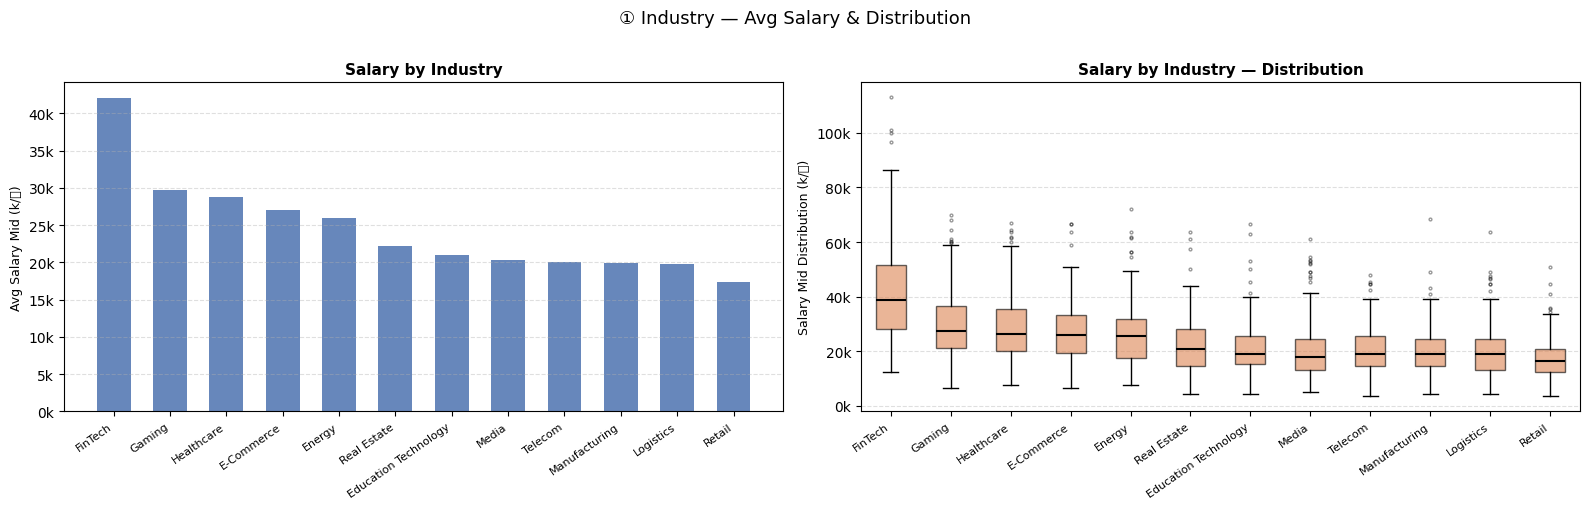

C:\Users\admin\AppData\Local\Temp\ipykernel_22452\897652329.py:92: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\admin\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


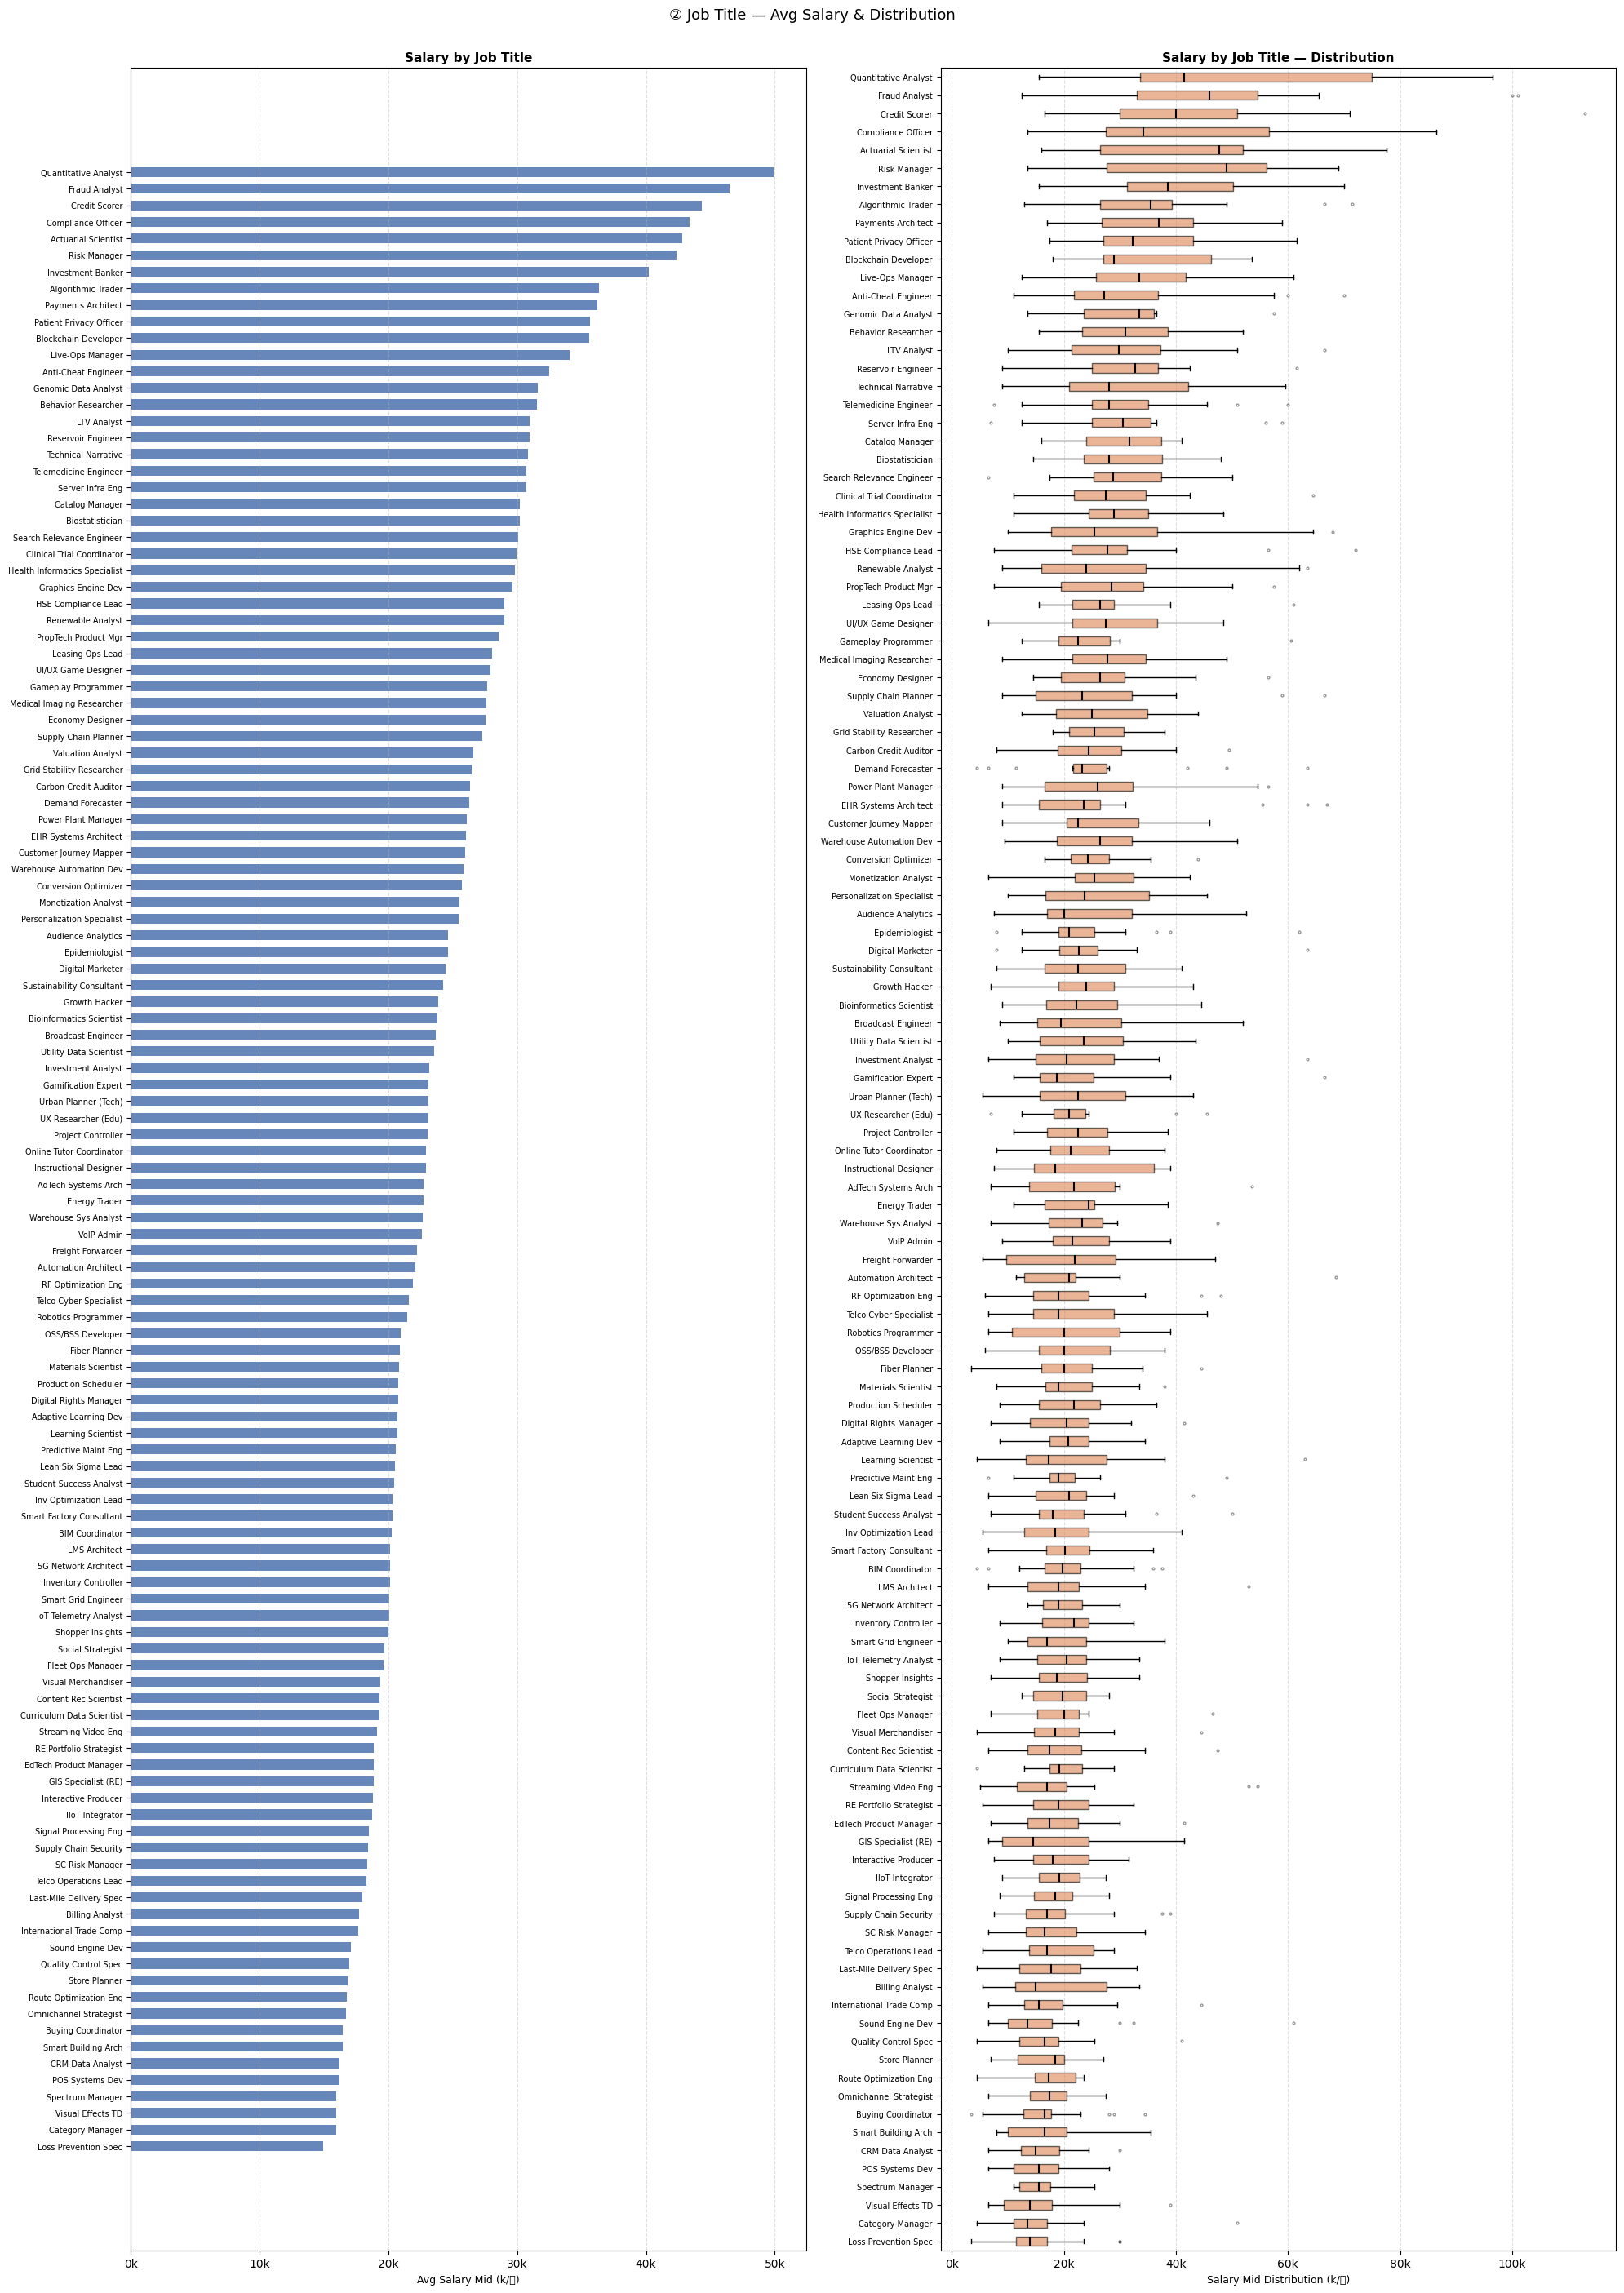

C:\Users\admin\AppData\Local\Temp\ipykernel_22452\897652329.py:101: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\admin\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


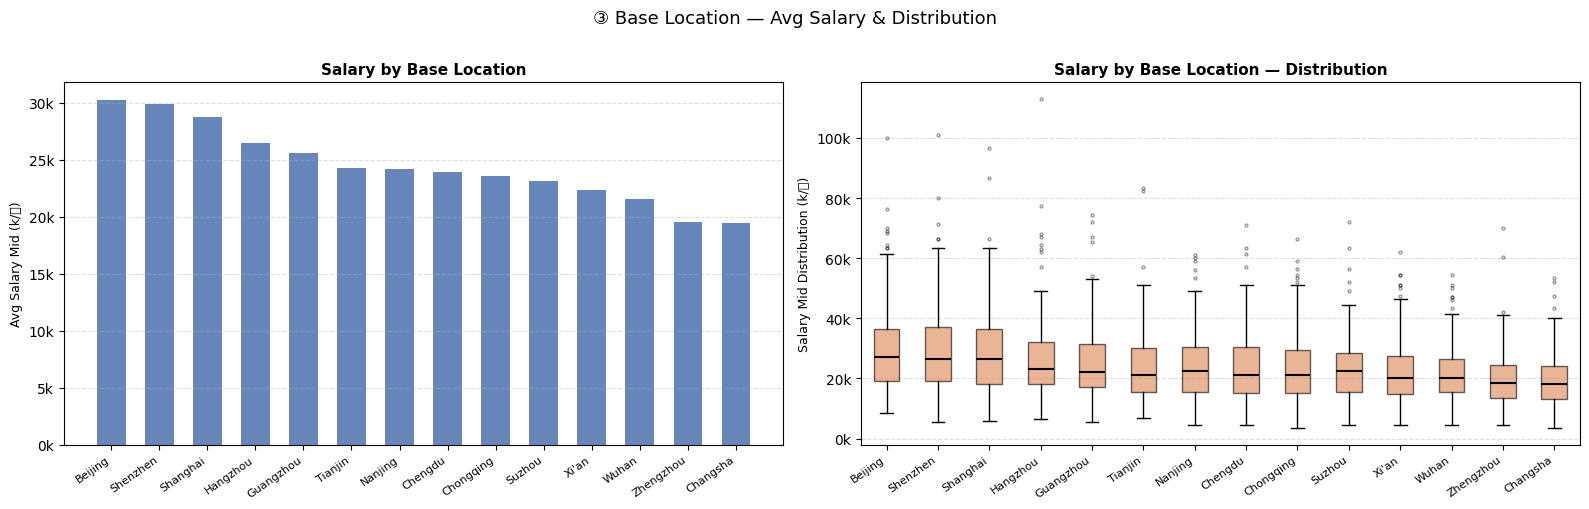

In [34]:
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── 解析薪资字符串 → 取区间均值（k RMB/月）────────────────────────────────
def parse_salary_mid(s):
    nums = re.findall(r'[\d.]+', str(s))
    if len(nums) >= 2:
        return (float(nums[0]) + float(nums[1])) / 2
    return float('nan')

df_jd['salary_mid'] = df_jd['salary'].apply(parse_salary_mid)

# ── 通用绘图函数 ───────────────────────────────────────────────────────────
def plot_salary_group(ax_bar, ax_box, data, group_col, title, orient='v'):
    grp = (data.groupby(group_col)['salary_mid']
               .mean()
               .sort_values(ascending=False))
    labels = grp.index.tolist()
    means  = grp.values
    box_data = [data.loc[data[group_col] == lbl, 'salary_mid'].dropna().values
                for lbl in labels]

    color_bar = '#4C72B0'
    color_box = '#DD8452'
    fmt_k = mticker.FormatStrFormatter('%.0fk')

    if orient == 'v':
        # ── 柱状图 ──
        ax_bar.bar(range(len(labels)), means, color=color_bar, alpha=0.85, width=0.6)
        ax_bar.set_xticks(range(len(labels)))
        ax_bar.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
        ax_bar.set_ylabel('Avg Salary Mid (k/月)', fontsize=9)
        ax_bar.yaxis.set_major_formatter(fmt_k)          # 薪资在 y 轴
        ax_bar.grid(axis='y', linestyle='--', alpha=0.4)

        # ── 箱线图 ──
        ax_box.boxplot(box_data, positions=range(len(labels)),
                       widths=0.5, patch_artist=True,
                       boxprops=dict(facecolor=color_box, alpha=0.6),
                       medianprops=dict(color='black', linewidth=1.5),
                       flierprops=dict(marker='o', markersize=2, alpha=0.4))
        ax_box.set_xticks(range(len(labels)))
        ax_box.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
        ax_box.set_ylabel('Salary Mid Distribution (k/月)', fontsize=9)
        ax_box.yaxis.set_major_formatter(fmt_k)          # 薪资在 y 轴
        ax_box.grid(axis='y', linestyle='--', alpha=0.4)

    else:  # horizontal
        # ── 柱状图 ──
        ax_bar.barh(range(len(labels)), means, color=color_bar, alpha=0.85, height=0.6)
        ax_bar.set_yticks(range(len(labels)))
        ax_bar.set_yticklabels(labels, fontsize=7)
        ax_bar.invert_yaxis()
        ax_bar.set_xlabel('Avg Salary Mid (k/月)', fontsize=9)
        ax_bar.xaxis.set_major_formatter(fmt_k)          # 薪资在 x 轴
        ax_bar.grid(axis='x', linestyle='--', alpha=0.4)

        # ── 箱线图 ──
        ax_box.boxplot(box_data, positions=range(len(labels)),
                       widths=0.5, patch_artist=True, vert=False,
                       boxprops=dict(facecolor=color_box, alpha=0.6),
                       medianprops=dict(color='black', linewidth=1.5),
                       flierprops=dict(marker='o', markersize=2, alpha=0.4))
        ax_box.set_yticks(range(len(labels)))
        ax_box.set_yticklabels(labels, fontsize=7)
        ax_box.invert_yaxis()
        ax_box.set_xlabel('Salary Mid Distribution (k/月)', fontsize=9)
        ax_box.xaxis.set_major_formatter(fmt_k)          # 薪资在 x 轴
        ax_box.grid(axis='x', linestyle='--', alpha=0.4)

    ax_bar.set_title(title, fontsize=11, fontweight='bold')
    ax_box.set_title(f'{title} — Distribution', fontsize=11, fontweight='bold')


# ═══════════════════════════════════════════════════════════════════════════
# 1. Industry（12 个，垂直）
# ═══════════════════════════════════════════════════════════════════════════
fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(16, 5))
plot_salary_group(ax1a, ax1b, df_jd, 'Industry', 'Salary by Industry', orient='v')
fig1.suptitle('① Industry — Avg Salary & Distribution', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# 2. Job Title（120 个，水平）
# ═══════════════════════════════════════════════════════════════════════════
fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(20, 28))
plot_salary_group(ax2a, ax2b, df_jd, 'Job Title', 'Salary by Job Title', orient='h')
fig2.suptitle('② Job Title — Avg Salary & Distribution', fontsize=13, y=1.002)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# 3. Base Location（14 个，垂直）
# ═══════════════════════════════════════════════════════════════════════════
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(16, 5))
plot_salary_group(ax3a, ax3b, df_jd, 'base_location', 'Salary by Base Location', orient='v')
fig3.suptitle('③ Base Location — Avg Salary & Distribution', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [14]:
### 1.2 Candidate Resume Generator — ~1000 records, ~200 words each


In [15]:
DEGREE_LEVELS = ["Associate's", "Bachelor's", "Master's", "Ph.D."]
DEGREE_FIELDS = [
    'Computer Science', 'Statistics', 'Applied Mathematics',
    'Electrical Engineering', 'Information Systems',
    'Data Science', 'Economics', 'Physics', 'Bioinformatics'
]
PERSONALITY_TRAITS = [
    'detail-oriented', 'results-driven', 'collaborative', 'innovative',
    'proactive', 'adaptable', 'analytical', 'strategic', 'self-motivated'
]
COMPANY_TYPES = [
    'a Fortune 500 company', 'a fast-growing startup', 'a leading tech firm',
    'a top-tier consulting firm', 'a global investment bank',
    'an e-commerce platform', 'a healthcare organization', 'a SaaS company'
]
ACHIEVEMENTS = [
    'Reduced model inference latency by 35% through architecture optimization.',
    'Built a real-time fraud detection system that saved $2M annually.',
    'Improved customer retention rate by 18% using personalization algorithms.',
    'Designed an automated reporting pipeline reducing manual effort by 40 hours per week.',
    'Led a cross-functional team of 6 engineers to deliver a recommendation engine on schedule.',
    'Published research on graph neural networks at a top-tier machine learning conference.',
    'Deployed a churn prediction model achieving 92% AUC in production.',
    'Migrated legacy ETL processes to Apache Spark, cutting runtime from 8 hours to 45 minutes.',
    'Increased ad click-through rate by 22% via multi-armed bandit experimentation.',
    'Developed an NLP pipeline for sentiment analysis processing 1M reviews daily.',
    'Reduced infrastructure costs by 30% through cloud resource optimization.',
    'Achieved top-5 ranking in an international data science competition (Kaggle).',
]

JOB_TITLES = df['Job Title'].unique()
SKILL_POOL = set()

for skills in df['Skills'].str.split(', '):
    SKILL_POOL.update(s.strip() for s in skills if s.strip())
SKILL_POOL = list(SKILL_POOL)


def generate_resume(candidate_id):
    name = fake.name()
    email = fake.email()
    total_years = random.randint(0, 18)
    current_title = random.choice(JOB_TITLES)
    degree = random.choice(DEGREE_LEVELS)
    field = random.choice(DEGREE_FIELDS)
    skills = random.sample(SKILL_POOL, k=random.randint(6, 12))
    traits = random.sample(PERSONALITY_TRAITS, k=3)
    achievements = random.sample(ACHIEVEMENTS, k=random.randint(2, 4))
    n_jobs = random.randint(1, 3)
    exp_sections = []
    remaining = total_years
    for j in range(n_jobs):
        duration = random.randint(1, max(1, remaining))
        remaining = max(0, remaining - duration)
        role = random.choice(JOB_TITLES)
        company = random.choice(COMPANY_TYPES)
        exp_sections.append(
            f"{role} at {company} ({duration} year{'s' if duration > 1 else ''}): "
            f"{random.choice(achievements)}"
        )
    resume_text = (
        f'Candidate: {name} | Email: {email}\n'
        f'Current Title: {current_title} | Total Experience: {total_years} year{"s" if total_years != 1 else ""}\n\n'
        f'Personal Summary:\n'
        f'I am a {", ".join(traits)} professional with a {degree} degree in {field}. '
        f'With {total_years} years of experience in the technology and data industry, I have a proven '
        f'track record of leveraging data-driven insights to solve complex business challenges. '
        f'I thrive in collaborative environments and am passionate about building robust, scalable systems '
        f'that create measurable impact. I am eager to contribute my expertise to a forward-thinking organization '
        f'that values innovation and continuous learning.\n\n'
        f'Work Experience:\n'
        + '\n'.join(f'- {e}' for e in exp_sections)
        + f'\n\nKey Skills:\n{", ".join(skills)}.\n\n'
        f'Education:\n'
        f'{degree} in {field} — {fake.company()} University, '
        f'Class of {random.randint(2005, 2023)}.\n\n'
        f'Certifications & Highlights:\n'
        f'- {random.choice(achievements)}\n'
        f'- Proficient in {random.choice(skills)} and {random.choice(skills)}.\n'
        f'- Fluent in English; conversational proficiency in {random.choice(["Mandarin", "Spanish", "French", "German", "Japanese"])}.\n'
    )
    return {
        'candidate_id': f'CV_{candidate_id:04d}',
        'name': name,
        'email': email,
        'current_title': current_title,
        'total_years_experience': total_years,
        'education_level': degree,
        'education_field': field,
        'skills': ', '.join(skills),
        'resume_text': resume_text
    }


N_CV = 1000
cv_records = [generate_resume(i) for i in range(1, N_CV + 1)]
df_cv = pd.DataFrame(cv_records)
print(f'Resume dataset shape: {df_cv.shape}')
print(df_cv[['candidate_id', 'name', 'current_title', 'total_years_experience', 'education_level']].head(3))
print('\nSample resume text (first 700 chars):\n')
print(df_cv['resume_text'].iloc[0][:700], '...')


Resume dataset shape: (1000, 9)
  candidate_id              name     current_title  total_years_experience  \
0      CV_0001      Allison Hill  Spectrum Manager                      16   
1      CV_0002  Jonathan Johnson     Store Planner                      12   
2      CV_0003   Abigail Shaffer  Spectrum Manager                      11   

  education_level  
0           Ph.D.  
1      Bachelor's  
2      Bachelor's  

Sample resume text (first 700 chars):

Candidate: Allison Hill | Email: donaldgarcia@example.net
Current Title: Spectrum Manager | Total Experience: 16 years

Personal Summary:
I am a results-driven, innovative, strategic professional with a Ph.D. degree in Physics. With 16 years of experience in the technology and data industry, I have a proven track record of leveraging data-driven insights to solve complex business challenges. I thrive in collaborative environments and am passionate about building robust, scalable systems that create measurable impact. I am eager t

In [16]:
df_cv

,candidate_id,name,email,current_title,total_years_experience,education_level,education_field,skills,resume_text
0,CV_0001,Allison Hill,donaldgarcia@example.net,Spectrum Manager,16,Ph.D.,Physics,"Navisworks, Environmental Regs, Java/Go, Predi...",Candidate: Allison Hill | Email: donaldgarcia@...
1,CV_0002,Jonathan Johnson,jennifermiles@example.com,Store Planner,12,Bachelor's,Information Systems,"Project Controls, Learning to Rank, ESG Report...",Candidate: Jonathan Johnson | Email: jenniferm...
2,CV_0003,Abigail Shaffer,jpeterson@example.org,Spectrum Manager,11,Bachelor's,Statistics,"MATLAB/Simulink, Survey Design, Reliability En...",Candidate: Abigail Shaffer | Email: jpeterson@...
3,CV_0004,Gregory Baker,blairamanda@example.com,Online Tutor Coordinator,5,Master's,Applied Mathematics,"Cartography, Logistics Coordination, Operation...",Candidate: Gregory Baker | Email: blairamanda@...
4,CV_0005,Shannon Ray,williamsjeremy@example.com,Supply Chain Planner,10,Ph.D.,Applied Mathematics,"Logistics Planning, Creative Writing, Thermody...",Candidate: Shannon Ray | Email: williamsjeremy...
...,...,...,...,...,...,...,...,...,...
995,CV_0996,Emily Blackburn,grios@example.org,Supply Chain Planner,16,Associate's,Physics,"Networking, Vendor Management, HIPAA/HITECH, E...",Candidate: Emily Blackburn | Email: grios@exam...
996,CV_0997,Jesse Oliver,kimberlylopez@example.com,Telco Cyber Specialist,16,Master's,Computer Science,"Data Privacy, Text Mining, Risk Assessment, Mi...",Candidate: Jesse Oliver | Email: kimberlylopez...
997,CV_0998,Mariah Thomas,mcgeejohn@example.com,Telco Operations Lead,10,Bachelor's,Electrical Engineering,"Negotiation, Legal Standards, Due Diligence, U...",Candidate: Mariah Thomas | Email: mcgeejohn@ex...
998,CV_0999,Jodi Baker,gomezjason@example.com,Audience Analytics,15,Master's,Statistics,"OSP Design, Energy Markets, Monetization Strat...",Candidate: Jodi Baker | Email: gomezjason@exam...


## 2. Structured Data Generation — 5000 records

Features include:
- **Numerical**: years of experience, salary, age, weekly hours, number of applications, match score
- **Categorical / Ordinal**: city, industry, gender, job level, education, political affiliation
- **Intentional missing values** (~3–12% per selected feature) to support imputation demonstration


## 3. Data Quality Check


In [21]:
print('=' * 55)
print('STRUCTURED DATA — Missing Value Report')
print('=' * 55)
missing_stats  = df_struct.isnull().sum()
missing_pct    = (df_struct.isnull().mean() * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing_stats, 'missing_%': missing_pct})
print(missing_report[missing_report['missing_count'] > 0].to_string())

print('\n' + '=' * 55)
print('STRUCTURED DATA — Basic Statistics')
print('=' * 55)
num_cols = ['years_experience', 'annual_salary_k', 'age', 'weekly_hours', 'num_applications', 'match_score']
print(df_struct[num_cols].describe().to_string())

print('\n' + '=' * 55)
print('JD Dataset — Word Count Statistics')
print('=' * 55)
jd_wc = df_jd['jd_text'].apply(lambda x: len(x.split()))
print(jd_wc.describe().to_string())

print('\n' + '=' * 55)
print('Resume Dataset — Word Count Statistics')
print('=' * 55)
cv_wc = df_cv['resume_text'].apply(lambda x: len(x.split()))
print(cv_wc.describe().to_string())


STRUCTURED DATA — Missing Value Report
                       missing_count  missing_%
years_experience                 255       5.10
annual_salary_k                  598      11.96
age                              316       6.32
weekly_hours                     433       8.66
num_applications                 175       3.50
match_score                      157       3.14
city                             338       6.76
education_level                  264       5.28
political_affiliation            466       9.32
education_ordinal                264       5.28

STRUCTURED DATA — Basic Statistics
       years_experience  annual_salary_k          age  weekly_hours  num_applications  match_score
count       4745.000000      4402.000000  4684.000000   4567.000000       4825.000000  4843.000000
mean           5.944362       354.059223    30.454099     44.535975          8.041244     0.626939
std            4.709327       290.850642     5.186736      5.351308          2.846574     0.162867
m

## 4. Save Datasets


In [19]:
import os

OUTPUT_DIR = r'E:\job_rec_data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_jd.to_csv(os.path.join(OUTPUT_DIR, 'jd_text_data.csv'),        index=False, encoding='utf-8-sig')

df_cv.to_csv(os.path.join(OUTPUT_DIR, 'resume_text_data.csv'),    index=False, encoding='utf-8-sig')
df_struct.to_csv(os.path.join(OUTPUT_DIR, 'structured_data.csv'), index=False, encoding='utf-8-sig')

print(f'Saved to {OUTPUT_DIR}:')
print(f'  jd_text_data.csv      — {len(df_jd):,} rows')
print(f'  resume_text_data.csv  — {len(df_cv):,} rows')
print(f'  structured_data.csv   — {len(df_struct):,} rows')
print('\nAll datasets are ready for downstream preprocessing.')


Saved to E:\job_rec_data:
  jd_text_data.csv      — 2,000 rows
  resume_text_data.csv  — 1,000 rows
  structured_data.csv   — 5,000 rows

All datasets are ready for downstream preprocessing.


In [8]:
import numpy as np
import random as _rnd

N_STRUCT = 5000

# JOB_LEVELS, CITIES, LEVEL_IDX, EDU_IDX defined in df_jd cell (shared constants)
GENDERS              = ['Male', 'Female']
GENDER_WEIGHTS       = [0.52, 0.48]

# Candidate-side level distribution (more junior candidates in the job market)
LEVEL_WEIGHTS_CANDIDATE = [0.05, 0.30, 0.20, 0.25, 0.10, 0.06, 0.03, 0.01]

EDUCATION_LEVELS     = ['High School', "Bachelor's", "Master's", 'Ph.D.']
EDU_WEIGHTS          = [0.06, 0.48, 0.37, 0.09]
POLITICAL_AFFILIATIONS = ['CPC Member', 'CPC Candidate', 'Democratic Party Member', 'Non-affiliated']
POLITICAL_WEIGHTS    = [0.30, 0.10, 0.05, 0.55]
INDUSTRIES           = df['Industry'].unique()

# Experience bands (years) and expected annual salary bands (万/year, range 5–60)
EXP_BANDS = {
    'Intern':   (0, 1),  'Junior':   (0, 3),  'Mid-level': (2, 7),   'Senior':   (5, 12),
    'Lead':     (7, 15), 'Manager':  (8, 18), 'Director':  (10, 20), 'VP':       (12, 25),
}
EXPECTED_SAL_BANDS = {
    'Intern':   (5,  10), 'Junior':   (8,  18), 'Mid-level': (12, 28), 'Senior':   (18, 40),
    'Lead':     (25, 50), 'Manager':  (30, 55), 'Director':  (35, 60), 'VP':       (45, 60),
}

def gen_expected_salary(level):
    """95% integer (62% end in 0/5), 5% one-decimal float."""
    lo, hi = EXPECTED_SAL_BANDS[level]
    if _rnd.random() < 0.05:
        return round(_rnd.uniform(lo, hi), 1)
    raw = _rnd.uniform(lo, hi)
    if _rnd.random() < 0.62:
        return float(max(lo, min(hi, round(raw / 5) * 5)))
    return float(round(raw))

# Title perturbation
TITLE_SYNONYMS = [
    ('Senior', 'Sr.'), ('Junior', 'Jr.'), ('Manager', 'Head of'),
    ('Engineer', 'Developer'), ('Analyst', 'Specialist'), ('UI/UX', 'UX/UI'),
    ('Machine Learning', 'ML'), ('Data Science', 'Data Analytics'),
    ('Game ', 'Gaming '), ('Cyber', 'InfoSec'), ('Product Manager', 'Product Lead'),
]

def perturb_title(title):
    for orig, repl in TITLE_SYNONYMS:
        if orig in title:
            return title.replace(orig, repl, 1)
    words = title.split()
    return ' '.join([words[1], words[0]] + words[2:]) if len(words) >= 2 else title

# Per-industry pools from df_jd (groupby, not iterrows)
_ind_titles = df_jd.groupby('Industry')['Job Title'].apply(list).to_dict()
_ind_skills = (df_jd.groupby('Industry')['Skills']
               .apply(lambda col: list(set(
                   s.strip() for row in col for s in row.split(',') if s.strip())))
               .to_dict())
_global_skills = list(set(
    s.strip() for sk in df_jd['Skills'] for s in sk.split(',') if s.strip()))

def get_expected_title(industry, idx):
    pool  = _ind_titles.get(industry) or df_jd['Job Title'].tolist()
    title = _rnd.choice(pool)
    return perturb_title(title) if idx % 5 == 0 else title

def get_candidate_skills(industry):
    pool = _ind_skills.get(industry) or _global_skills
    return ', '.join(_rnd.sample(pool, min(_rnd.randint(5, 8), len(pool))))

# ── Core attributes ─────────────────────────────────────────────────────────
job_levels_s = np.random.choice(JOB_LEVELS,            size=N_STRUCT, p=LEVEL_WEIGHTS_CANDIDATE)
industries_s = np.random.choice(INDUSTRIES,             size=N_STRUCT)
cities_s     = np.random.choice(CITIES,                 size=N_STRUCT)
genders_s    = np.random.choice(GENDERS,                size=N_STRUCT, p=GENDER_WEIGHTS)
educations_s = np.random.choice(EDUCATION_LEVELS,       size=N_STRUCT, p=EDU_WEIGHTS)
politics_s   = np.random.choice(POLITICAL_AFFILIATIONS, size=N_STRUCT, p=POLITICAL_WEIGHTS)

years_exp        = np.array([_rnd.randint(*EXP_BANDS[l]) for l in job_levels_s], dtype=float)
age              = np.clip(years_exp + np.random.randint(22, 28, N_STRUCT)
                           + np.random.randint(-2, 3, N_STRUCT), 18, 60).astype(float)
expected_salary  = np.array([gen_expected_salary(l) for l in job_levels_s], dtype=float)
weekly_hours     = np.clip(
    np.where(np.isin(job_levels_s, ['Manager', 'Director', 'VP']),
             np.random.normal(50, 6, N_STRUCT), np.random.normal(44, 5, N_STRUCT)),
    30, 80).round(1)
num_applications = np.random.poisson(lam=8, size=N_STRUCT).astype(float)
expected_titles  = [get_expected_title(ind, i) for i, ind in enumerate(industries_s)]
skills_s         = [get_candidate_skills(ind) for ind in industries_s]

# ── Introduce missing values ─────────────────────────────────────────────────
MISSING_CONFIG = [
    ('years_experience', years_exp,       0.05), ('expected_salary_k', expected_salary, 0.08),
    ('age',              age,             0.06), ('weekly_hours',      weekly_hours,    0.08),
    ('num_applications', num_applications,0.04),
]
_missing = {}
for _col, _arr, _rate in MISSING_CONFIG:
    _a = np.array(_arr, dtype=object)
    _a[np.random.rand(N_STRUCT) < _rate] = np.nan
    _missing[_col] = _a

cities_m     = np.array(cities_s,     dtype=object); cities_m    [np.random.rand(N_STRUCT) < 0.07] = np.nan
educations_m = np.array(educations_s, dtype=object); educations_m[np.random.rand(N_STRUCT) < 0.05] = np.nan
politics_m   = np.array(politics_s,   dtype=object); politics_m  [np.random.rand(N_STRUCT) < 0.10] = np.nan

# ── Assemble DataFrame ───────────────────────────────────────────────────────
df_struct = pd.DataFrame({
    'record_id':             [f'REC_{i:05d}' for i in range(1, N_STRUCT + 1)],
    'years_experience':      _missing['years_experience'].astype(float),
    'expected_salary_k':     _missing['expected_salary_k'].astype(float),   # 万/year, 5-60
    'age':                   _missing['age'].astype(float),
    'weekly_hours':          _missing['weekly_hours'].astype(float),
    'num_applications':      _missing['num_applications'].astype(float),
    'gender':                genders_s,
    'job_level':             job_levels_s,
    'industry':              industries_s,
    'city':                  cities_m,
    'education_level':       educations_m,
    'political_affiliation': politics_m,
    'expected_title':        expected_titles,
    'skills':                skills_s,
})
edu_order   = {v: i for i, v in enumerate(EDUCATION_LEVELS)}
level_order = {v: i for i, v in enumerate(JOB_LEVELS)}
df_struct['education_ordinal'] = df_struct['education_level'].map(edu_order)
df_struct['job_level_ordinal']  = df_struct['job_level'].map(level_order)

# ── Ground Truth: vectorised heuristic (N × M) ───────────────────────────────
# Score = industry×3 + level_proximity×2 + salary_match×2 + edu_meets_req×1
# expected_salary_k: 万/year → monthly k RMB = val * 10/12  (same unit as salary_mid)
print('Computing ground truth labels (vectorised) ...')

j_ind = np.array(df_jd['Industry'].values, dtype=str)
j_lvl = np.array([LEVEL_IDX.get(l, 3) for l in df_jd['job_level'].values])
j_sal = df_jd['salary_mid'].values.astype(float)
j_edu = np.array([EDU_IDX.get(e, 1) for e in df_jd['edu_req'].values])

p_ind = np.array(df_struct['industry'].values, dtype=str)
p_lvl = np.array([LEVEL_IDX.get(l, 3) for l in df_struct['job_level'].values])
p_sal = df_struct['expected_salary_k'].values.astype(float) * 10 / 12
p_edu = np.array([EDU_IDX.get(str(e), 1) for e in df_struct['education_level'].values])

ind_score = (p_ind[:, None] == j_ind[None, :]).astype(np.float32) * 3.0
lvl_diff  = np.abs(p_lvl[:, None].astype(np.float32) - j_lvl[None, :].astype(np.float32))
lvl_score = np.maximum(0.0, 1.0 - lvl_diff * 0.3) * 2.0

sal_valid = ~np.isnan(p_sal)
p_s2d = np.where(sal_valid, p_sal, 0.0)[:, None].astype(np.float32)
j_s2d = j_sal[None, :].astype(np.float32)
max_s = np.maximum(p_s2d, j_s2d)
sal_score = np.where(max_s > 0, np.minimum(p_s2d, j_s2d) / max_s, 0.5).astype(np.float32) * 2.0
sal_score[~sal_valid] = 1.0   # neutral when salary unknown

edu_score = (p_edu[:, None] >= j_edu[None, :]).astype(np.float32)

best_idxs = np.argmax(ind_score + lvl_score + sal_score + edu_score, axis=1)
df_struct['ground_truth_jd_id'] = df_jd['jd_id'].iloc[best_idxs].values

print(f'Structured dataset shape: {df_struct.shape}')
print(df_struct[['record_id', 'job_level', 'industry',
                  'expected_salary_k', 'expected_title',
                  'ground_truth_jd_id']].head(8).to_string())
print(f"\nGround truth: {df_struct['ground_truth_jd_id'].nunique()} unique JDs / {len(df_jd)} total")
df_struct.head(5)

Computing ground truth labels (vectorised) ...
Structured dataset shape: (5000, 17)
   record_id  job_level              industry  expected_salary_k              expected_title ground_truth_jd_id
0  REC_00001     Senior            E-Commerce               24.0  Specialist Personalization            JD_0451
1  REC_00002     Senior  Education Technology               20.0         UX Researcher (Edu)            JD_0961
2  REC_00003     Junior           Real Estate               15.0             BIM Coordinator            JD_0673
3  REC_00004    Manager               Telecom               32.0       Signal Processing Eng            JD_0304
4  REC_00005     Junior  Education Technology               15.0               LMS Architect            JD_1492
5  REC_00006  Mid-level         Manufacturing               20.0             Integrator IIoT            JD_1049
6  REC_00007     Junior               Telecom               10.0        5G Network Architect            JD_0518
7  REC_00008       L

,record_id,years_experience,expected_salary_k,age,weekly_hours,num_applications,gender,job_level,industry,city,education_level,political_affiliation,expected_title,skills,education_ordinal,job_level_ordinal,ground_truth_jd_id
0,REC_00001,5.0,24.0,28.0,50.8,NaN,Male,Senior,E-Commerce,Guangzhou,Master's,CPC Member,Specialist Personalization,"UX Research, Supply Chain Management, Customer...",2.0,3,JD_0451
1,REC_00002,12.0,20.0,34.0,45.7,7.0,Female,Senior,Education Technology,Chongqing,Master's,Non-affiliated,UX Researcher (Edu),"Wireframing, Operations Management, Cloud Comp...",2.0,3,JD_0961
2,REC_00003,2.0,15.0,22.0,43.9,6.0,Male,Junior,Real Estate,Chongqing,Master's,CPC Member,BIM Coordinator,"Excel, Revit, IoT Architecture, Negotiation, G...",2.0,1,JD_0673
3,REC_00004,12.0,32.0,35.0,55.2,11.0,Female,Manager,Telecom,Beijing,Master's,NaN,Signal Processing Eng,"NFV/SDN, Networking (QoS), DSP, Data Analysis,...",2.0,5,JD_0304
4,REC_00005,1.0,15.0,NaN,39.3,7.0,Female,Junior,Education Technology,Shenzhen,High School,Non-affiliated,LMS Architect,"Database Design, Data Visualization, R, Qualit...",0.0,1,JD_1492


In [11]:
import os
df_struct.to_csv('E:\\Xgboost\\structured_data.csv', index=False, encoding='utf-8-sig')